# Hopfield Network — Pattern Storage and Reconstruction

**Laboratory of Computational Physics — Project Report**

| | |
|---|---|
| **Model** | Classical Hopfield network (binary spins, $S_i \in \{+1,-1\}$) |
| **Datasets** | Random 2-D patterns · MNIST digit prototypes |
| **Learning rules** | Hebbian · Local (radius R) |
| **Update methods** | Synchronous · Asynchronous · Monte Carlo (Metropolis) |

---

## Structure

1. [Theory recap](#1-theory)
2. [Setup & imports](#2-setup)
3. [Part A — Storing patterns: the J matrix](#3-part-a)
4. [Part B — Corrupting patterns](#4-part-b)
5. [Part C — Recovery: sign rule & Monte Carlo](#5-part-c)
6. [Part D — Storage capacity & overlap](#6-part-d)
7. [MNIST — digit prototypes](#7-mnist)
8. [Conclusions](#8-conclusions)


---
<a id="1-theory"></a>
## 1 — Theory recap

A Hopfield network is a fully connected recurrent network of $N$ binary neurons
$S_i \in \{+1,-1\}$ with symmetric, zero-diagonal coupling matrix $J_{ij}$.
Its Hamiltonian (energy function) is:

$$
H[\mathbf{S}] = -\frac{1}{2}\sum_{i \neq j} J_{ij} S_i S_j
$$

This is identical to the Ising spin-glass Hamiltonian with quenched disorder in
the couplings.  The couplings are chosen so that $P$ desired *patterns*
$\{\boldsymbol{\xi}^\mu\}_{\mu=1}^P$ are local energy minima (attractors).

### Hebbian learning

$$
J_{ij} = \frac{1}{N}\sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu, \qquad J_{ii}=0
$$

### Synchronous (sign) update rule

$$
S_i(t+1) = \operatorname{sgn}\!\left(\sum_j J_{ij} S_j(t)\right)
$$

**Note on convergence:** strictly speaking, monotonic energy decrease is guaranteed only for *asynchronous* updates (one spin at a time). Synchronous updates (all spins updated simultaneously) can in principle produce period-2 limit cycles rather than fixed points. In practice, for the parameter regimes used here, the synchronous rule does converge, but this should be kept in mind when interpreting the energy trace.

### Monte Carlo / Metropolis update

A random spin $i$ is selected; the energy change of flipping it is

$$
\Delta E_i = 2\,S_i\!\sum_j J_{ij}S_j
$$

The flip is accepted if $\Delta E_i \le 0$, otherwise with probability
$e^{-\Delta E_i/T}$.  Temperature $T$ allows the network to escape shallow
spurious minima.

### Storage capacity

The maximum number of storable patterns for reliable retrieval is approximately

$$
P_c \approx 0.138\,N
$$

Beyond this limit, interference between stored patterns degrades retrieval.


---
<a id="2-setup"></a>
## 2 — Setup & imports


In [41]:
import os
import sys
from pathlib import Path
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
import torch
import time

# add the notebook directory to sys.path so the project modules import cleanly
_project_dir = Path(".").resolve()
if str(_project_dir) not in sys.path:
    sys.path.insert(0, str(_project_dir))

from funzioni_ausiliari_v2 import hopfield_model_torch, plot_corruption_modes, plot_all_results, plot_energy_trace, plot_overlap_vs_q, plot_overlap_vs_P, plot_capacity_heatmap, compute_phase_diagram, plot_phase_diagram
from patterns_v2 import generate_random_patterns, corrupt_patterns, get_mnist_patterns

os.makedirs('plots', exist_ok=True)

SEED = 42
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
<a id="3-part-a"></a>
## 3 — Part A: Storing patterns — the coupling matrix $J$

Given $P$ patterns we compute $J$ with the **Hebbian rule**:

$$
J_{ij} = \frac{1}{N}\sum_{\mu=1}^P \xi_i^\mu \xi_j^\mu
$$

We can visualise $J$ directly: positive entries (blue) link neurons that tend
to be *co-activated*; negative entries (red) link neurons with *opposite* states.


/tmp/ipykernel_3900/3699595459.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


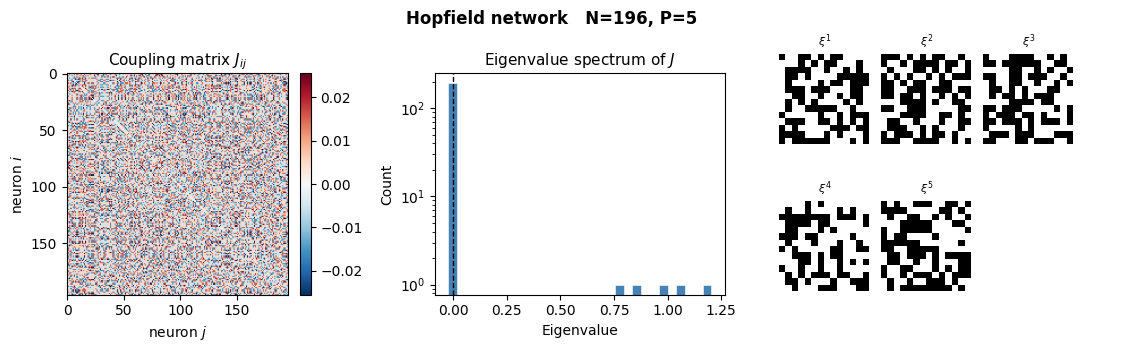

Theoretical capacity: P_c = 27.0
Memory interference:  I  = 0.0633


In [2]:
shape = (14, 14)
N = shape[0] * shape[1]
n_patterns = 5

patterns = generate_random_patterns(shape, n_patterns, seed=SEED)
model = hopfield_model_torch(patterns, update_method='synchronous', learning_rule='hebb', verbose=False)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

im = axes[0].imshow(model.J.cpu().numpy(), cmap='RdBu_r', vmin=-model.J.abs().max().item(), vmax=model.J.abs().max().item())
axes[0].set_title('Coupling matrix $J_{ij}$', fontsize=11)
axes[0].set_xlabel('neuron $j$'); axes[0].set_ylabel('neuron $i$')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# eigenvalue spectrum
eigvals = torch.linalg.eigvalsh(model.J.cpu()).numpy()
axes[1].hist(eigvals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_yscale('log')
axes[1].axvline(0, color='k', linestyle='--', linewidth=1)
axes[1].set_title('Eigenvalue spectrum of $J$', fontsize=11)
axes[1].set_xlabel('Eigenvalue'); axes[1].set_ylabel('Count')

# stored patterns
axes[2].axis('off')
for mu, p in enumerate(patterns):
    ax_in = fig.add_axes([0.69 + (mu % 3) * 0.085, 0.55 - (mu // 3) * 0.42, 0.075, 0.35])
    ax_in.imshow((p + 1) / 2, cmap='gray', vmin=0, vmax=1)
    title_str = r'$\xi^{' + str(mu + 1) + r'}$'
    ax_in.set_title(title_str, fontsize=8)
    ax_in.axis('off')

plt.suptitle(f'Hopfield network   N={N}, P={n_patterns}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Theoretical capacity: P_c = {model.storage_limit():.1f}")
print(f"Memory interference:  I  = {float(model.memory_interference()):.4f}")

**Reading the spectrum.** When $P \ll P_c$ the spectrum of $J$ is dominated
by $P$ large eigenvalues — each corresponding to a stored pattern — embedded in
a semicircular bulk of noise eigenvalues (Marchenko–Pastur law).  As $P$
approaches $P_c$ the signal eigenvalues are no longer separated from the noise
and retrieval fails.


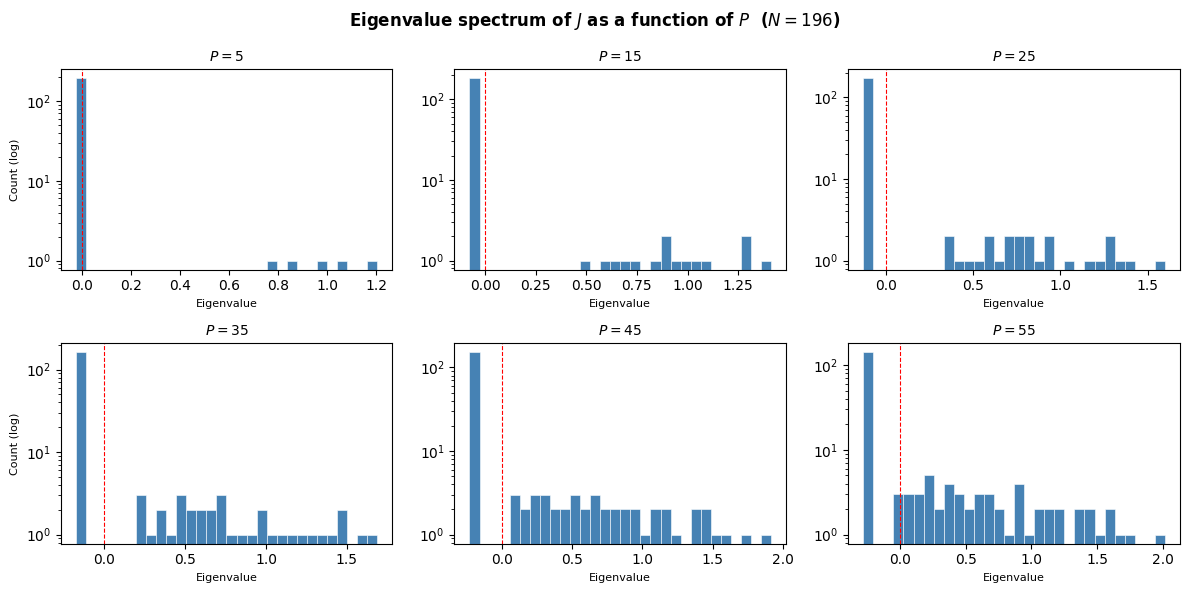

In [3]:
shape = (14, 14)
N = shape[0] * shape[1]
P_values = list(range(5, 56, 10))

fig = plt.figure(figsize=(12, 6))
for idx, P in enumerate(P_values):
    ax = fig.add_subplot(2, 3, idx + 1)

    patterns = generate_random_patterns(shape, P, seed=SEED)
    model = hopfield_model_torch(patterns, update_method='synchronous', learning_rule='hebb', verbose=False)
    eigvals = torch.linalg.eigvalsh(model.J.cpu()).numpy()
    ax.hist(eigvals, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.axvline(0, color='r', linestyle='--', linewidth=0.8)
    ax.set_title(f'$P = {P}$', fontsize=10)
    ax.set_xlabel('Eigenvalue', fontsize=8)
    if idx % 3 == 0:
        ax.set_ylabel('Count (log)', fontsize=8)

fig.suptitle(r'Eigenvalue spectrum of $J$ as a function of $P$  ($N=196$)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Eigenvalue spectrum and storage capacity.**
As the number of stored patterns $P$ increases, the patterns become
progressively less orthogonal and their mutual interference grows.
This is directly visible in the eigenvalue spectrum of $J$.

For small $P$, the spectrum shows $P$ isolated large eigenvalues — one per
stored pattern — sitting well above a bulk of values clustered near zero.
Each signal eigenvalue is approximately equal to $1$, since
$J = \frac{1}{N}\sum_\mu \boldsymbol{\xi}^\mu (\boldsymbol{\xi}^\mu)^T$
and the patterns are nearly orthogonal.

As $P$ grows, the bulk eigenvalues are no longer concentrated at zero but
spread into a continuous cloud whose shape is well described by the
**Marchenko–Pastur distribution** from random matrix theory.
For a matrix with aspect ratio $\alpha = P/N$, the bulk extends over the
interval $[(1-\sqrt{\alpha})^2,\, (1+\sqrt{\alpha})^2]$.
The capacity limit $P_c \approx 0.138\,N$ corresponds precisely to the
point at which the upper edge of this noise cloud reaches the signal
eigenvalues: beyond $P_c$ the network can no longer distinguish a genuine
memory from a random linear combination of stored patterns, and reliable
retrieval breaks down.

**`Obs`**: <br> Since $J_{ii} = 0$, we have $\text{Tr}(J) = 0$, which forces the sum of all
eigenvalues to zero. The $P$ large positive eigenvalues associated with the
stored patterns are therefore balanced by a bulk of negative eigenvalues,
producing the leftward shift visible in the spectra above.

---
<a id="4-part-b"></a>
## 4 — Part B: Corrupting patterns

The standard corruption model flips each spin independently with probability
$(1-q)$.  We also implement three spatially structured corruption modes that
are more realistic models of real-world signal degradation:

| Mode | Description |
|---|---|
| **Random** | Each pixel flipped with uniform probability $1-q$ |
| **Radial** | Centre of the image is well preserved; corruption increases towards the edges |
| **Block** | A contiguous rectangular patch is completely wiped |
| **Gradient** | Corruption grows linearly from top to bottom (or left to right) |

The radial and gradient modes are interesting because they preserve spatial
structure — the network must *extrapolate* to the corrupted region rather than
average over isotropic noise.


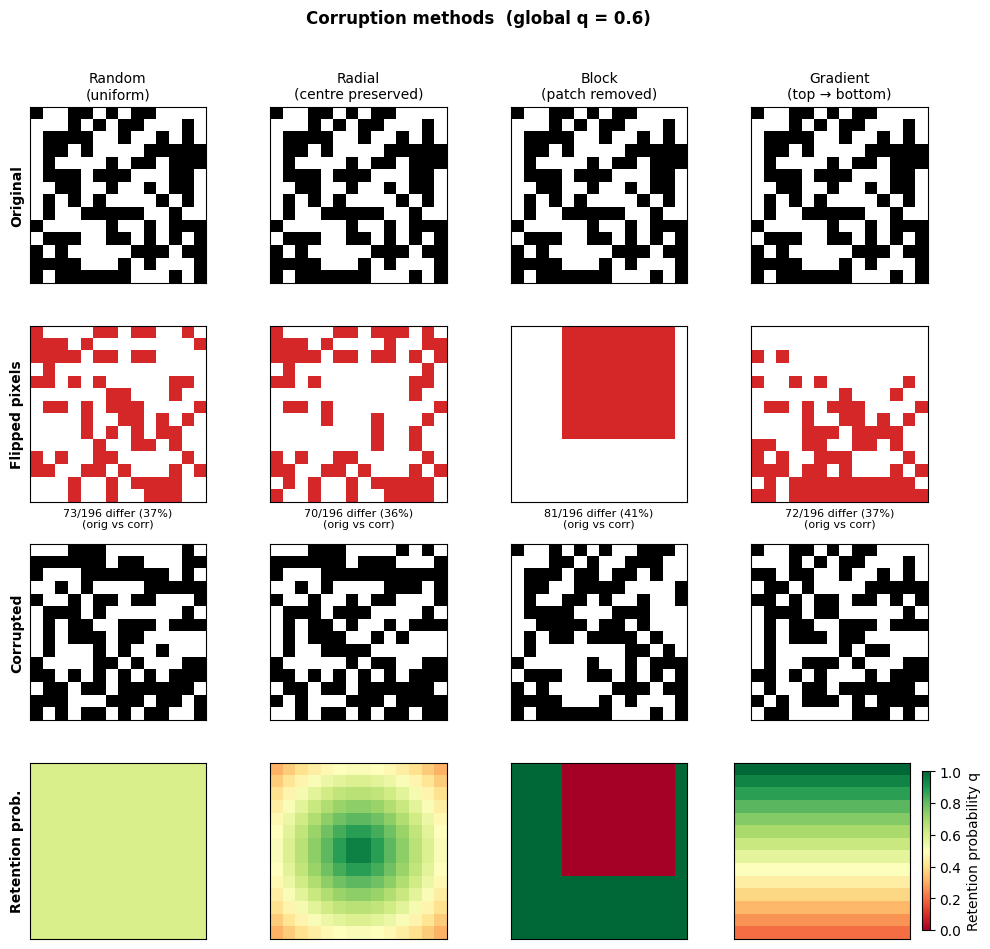

In [5]:
shape, P = (14, 14), 20
patterns = generate_random_patterns(shape, P, seed=SEED)
sample_pattern = patterns[0]

plot_corruption_modes(sample_pattern, q=0.6, radial_kwargs={})

The new **flipped-pixel map** (second row) is the ground truth: it marks in
red every pixel where the corrupted image differs from the original.
Comparing it with the **retention-probability map** (bottom row) makes the
spatial structure of each mode explicit:

- *random* — uniform retention; the flipped pixels are scattered isotropically;
- *radial* — a central plateau ($q \!=\! 1$ for $r < r_0$) is perfectly
  preserved, then $q$ ramps down to $q_\text{edge}$ at the corners;
- *block* — retention is 0 inside the patch and 1 outside, so all flipped
  pixels lie inside the rectangle;
- *gradient* — a vertical ramp; the flip density grows top to bottom.

**Why the retention map can go all the way down to $q = 0$.**
$q$ is defined as the *per-pixel survival probability*, not as a measure of
how recoverable the image is. The two are not the same: at $q = 0$ **every**
pixel is flipped, so the corrupted image is *exactly* $-\xi^\mu$, the inverse
of the original. This is in fact a perfectly recoverable input — the Hopfield
energy is symmetric under $\mathbf{S}\to-\mathbf{S}$, so both $\xi^\mu$ and
$-\xi^\mu$ are attractors, and recovery from $-\xi^\mu$ gives $m = -1$
(*"correct up to a global sign flip"*). The hardest regime is **$q = 0.5$**:
there the corrupted image is statistically uncorrelated with $\xi^\mu$ and
the network has no information left to choose between $\xi^\mu$ and $-\xi^\mu$.
We will see this symmetry-breaking transition explicitly in the $m(q)$ curves
of Section 6.1, where $m$ drops to $-1$ (not 0) below $q^* \approx 0.5$.

Notice how the **retention-probability map** (bottom row) reveals the spatial
structure of each mode.  For *random* corruption the map is flat; for *radial*
it is brightest at the centre; for *gradient* it fades from top to bottom.


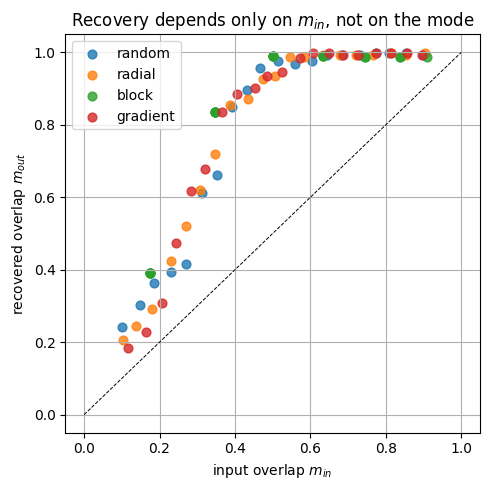

In [6]:
shape, P = (14, 14), 20
patterns = generate_random_patterns(shape, P, seed=SEED)
model = hopfield_model_torch(patterns, update_method='synchronous', learning_rule='hebb', verbose=False)

modes = ['random', 'radial', 'block', 'gradient']
qs = np.linspace(0.95, 0.55, 20)   # stay above q* ~ 0.5 to avoid the sign flip
results = {m: {'m_in': [], 'm_out': []} for m in modes}

for mode in modes:
    for q in qs:
        corr = corrupt_patterns(patterns, q, method=mode, seed=SEED)
        rec = model.correct_patterns(np.array([c.reshape(shape) for c in corr]))
        m_in = np.mean([abs(float(model.overlap(patterns[k], corr[k]))) for k in range(P)])
        m_out = np.mean([abs(float(model.overlap(patterns[k], rec[k].ravel()))) for k in range(P)])
        results[mode]['m_in'].append(m_in); results[mode]['m_out'].append(m_out)

plt.figure(figsize=(5,5))
for mode in modes:
    plt.scatter(results[mode]['m_in'], results[mode]['m_out'], label=mode, s=40, alpha=.8)
plt.plot([0,1],[0,1],'k--',lw=.7)
plt.xlabel('input overlap $m_{in}$')
plt.ylabel('recovered overlap $m_{out}$')
plt.legend()
plt.title('Recovery depends only on $m_{in}$, not on the mode')
plt.grid(True)
plt.tight_layout(); plt.show()

**Result — the spatial mode of corruption is irrelevant.**

With all four modes calibrated to the same global level (flipped fraction
$1-q$, differing only in *where* the corruption sits), the recovery curves
collapse onto a single curve: random, radial, block and gradient are
indistinguishable within sampling noise across the whole $q$ range.

This is exactly what the dynamics predicts. Recovery is governed by the
**global overlap** $m = \frac{1}{N}\sum_i S_i\,\xi_i^\mu$, and each local
field $h_i = \sum_j J_{ij} S_j$ sums over the *entire* network — so the
update is blind to the spatial arrangement of the flipped pixels and sees
only their total count. At equal $q$ the four modes feed the network the
same overlap, hence the same recovery.

Two consequences follow: (i) for uncorrelated random patterns the
*geometry* of the corruption carries no information for retrieval — only its
*amount* does; (ii) this justifies using the simplest `random` mode in every
recovery experiment that follows, without loss of generality. The picture
changes for spatially **correlated** patterns (e.g. MNIST, Section 7), where
a block erasing the discriminative pixels of a digit is much harder to
recover than scattered noise of the same size.

---
<a id="5-part-c"></a>
## 5 — Part C: Pattern recovery

### 5.1 Sign (synchronous) update

Starting from a corrupted state $\mathbf{y}^a$, the synchronous rule

$$
S_i(t+1) = \operatorname{sgn}\!\left(\sum_j J_{ij} S_j(t)\right)
$$

is applied iteratively until convergence.  For *asynchronous* updates each spin flip strictly decreases the energy, guaranteeing convergence to a fixed point. For the *synchronous* version used here all spins are updated in parallel; the energy is not guaranteed to decrease at every step (period-2 cycles are possible in principle), but in the regime $P \ll P_c$ the dynamics converges in practice to a fixed point that is either the target pattern or a spurious minimum.


Converged after 4 iterations
Converged after 10 iterations
Converged after 4 iterations
Converged after 100 iterations
Converged after 100 iterations
Converged after 6 iterations
Converged after 4 iterations
Converged after 13 iterations
Converged after 100 iterations
Converged after 8 iterations
Converged after 9 iterations
Converged after 8 iterations
Converged after 10 iterations
Converged after 7 iterations
Converged after 5 iterations
Converged after 5 iterations
Converged after 4 iterations
Converged after 10 iterations
Converged after 4 iterations
Converged after 4 iterations


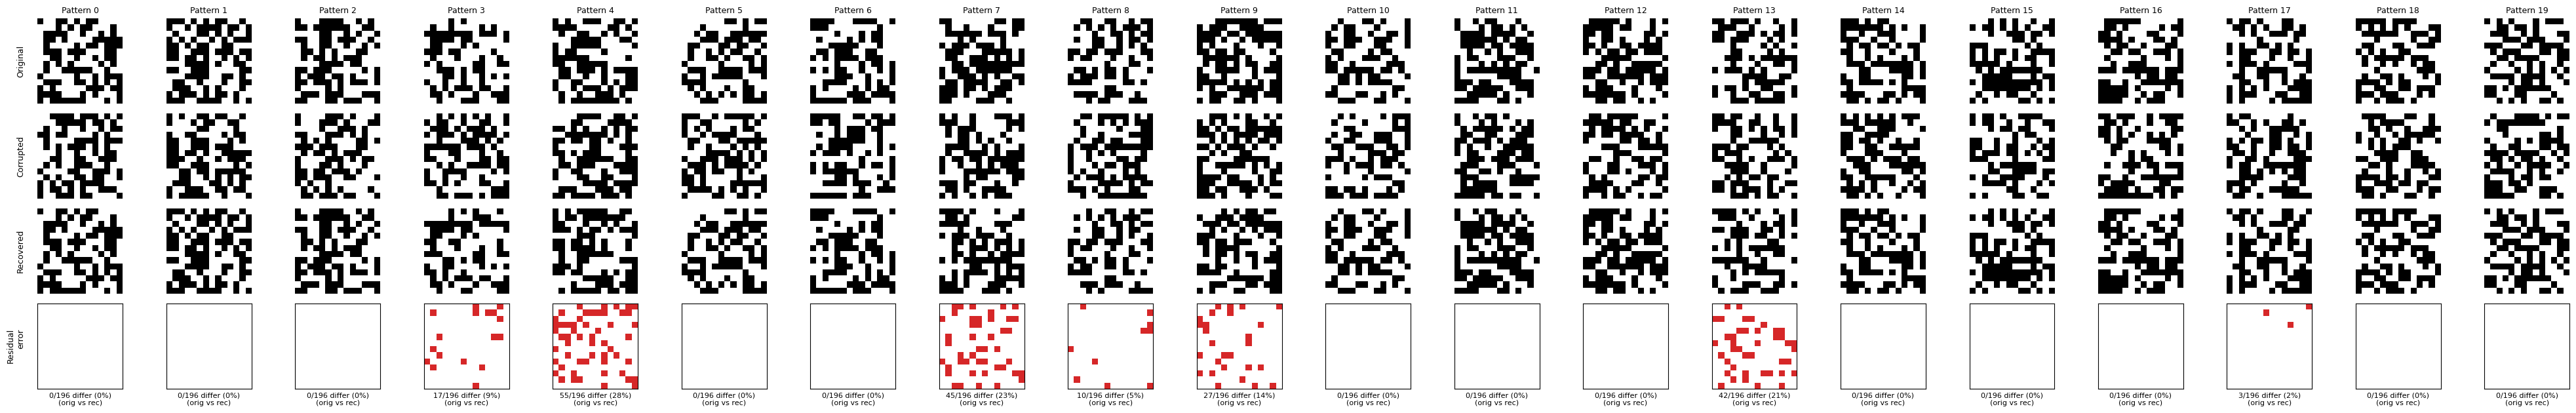

In [7]:
shape = (14, 14)
n_patterns = 20
q = 0.7

patterns = generate_random_patterns(shape, n_patterns, seed=SEED)
corrupted = corrupt_patterns(patterns, q, method='random', seed=SEED)

model = hopfield_model_torch(patterns, update_method='synchronous', learning_rule='hebb', verbose=True)
recovered = model.correct_patterns(np.array([c.reshape(shape) for c in corrupted]))

plot_all_results(patterns, corrupted, recovered, model=model)

### 5.2 Energy trace during recovery

Plotting the energy as a function of iteration confirms that the dynamics
is a *gradient descent* on the energy landscape.


/mnt/c/Users/andre/OneDrive/Desktop/HOPFIELD_MODEL_PROJECT/HOPFIELD MODEL PROJECT/funzioni_ausiliari_v2.py:516: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pattern = torch.tensor(pattern.flatten(),


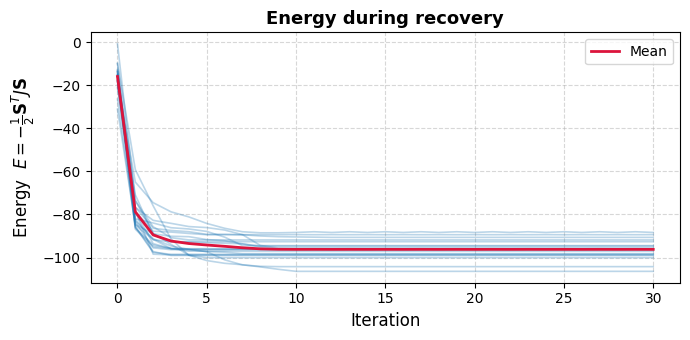

In [ ]:
_ = plot_energy_trace(model, corrupted, max_iter=30)

### Energy during synchronous recovery

The energy $H[\mathbf{S}] = -\frac{1}{2}\sum_{i\neq j}J_{ij}S_iS_j$ provides a measure of how close the current state is to a stored attractor. Starting from the corrupted pattern the energy decreases (or stays constant) at each iteration: the dynamics is effectively a **gradient descent** on the energy landscape.

The trace typically shows a rapid drop in the first 1–3 iterations, after which the energy plateaus — the network has reached a fixed point (either the correct pattern or a spurious minimum).  A longer, slower descent can signal proximity to a saddle point or an almost-degenerate spurious minimum.

**Note:** strictly speaking, monotonic energy decrease holds only for asynchronous (one-spin-at-a-time) updates.  With synchronous updates small oscillations are possible, but the energy trace confirms that for the parameter regime used here ($P \ll P_c$, $q > 0.5$) convergence is clean and rapid.


# Asynchronous update

Converged after 9 iterations
Converged after 16 iterations
Converged after 27 iterations
Converged after 10 iterations
Converged after 12 iterations
Converged after 19 iterations
Converged after 10 iterations
Converged after 12 iterations
Converged after 14 iterations
Converged after 11 iterations
Converged after 18 iterations
Converged after 9 iterations
Converged after 13 iterations
Converged after 13 iterations
Converged after 23 iterations
Converged after 10 iterations
Converged after 11 iterations
Converged after 12 iterations
Converged after 9 iterations
Converged after 9 iterations


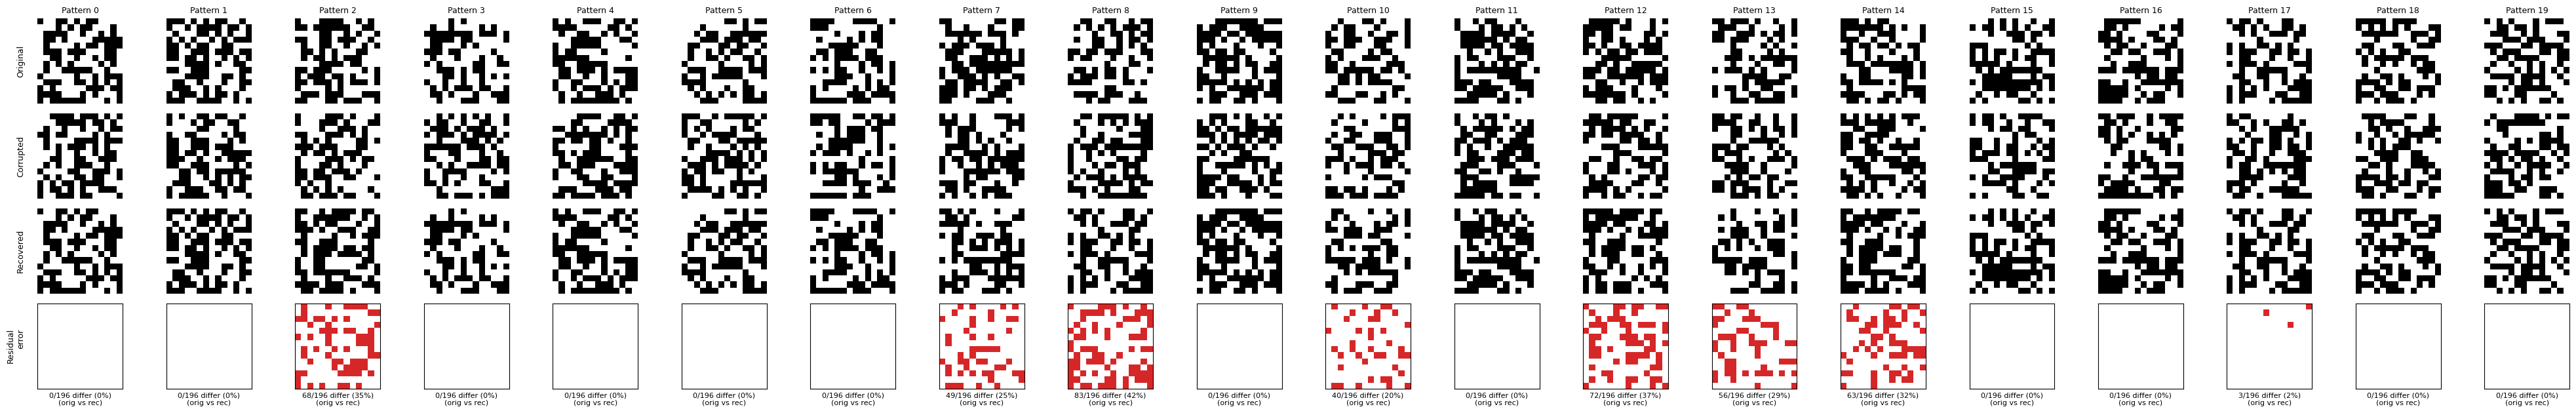

In [ ]:
# Recovery: asynchronous update
# Same setup as the synchronous run above, but spins are flipped one at a time
# in random order. This is the update for which Hopfield (1982) proved that
# the energy is monotonically non-increasing — convergence to a local minimum
# is guaranteed in finite time, with no period-2 oscillations.

shape = (14, 14)
n_patterns = 20
q = 0.7

patterns = generate_random_patterns(shape, n_patterns, seed=SEED)
corrupted = corrupt_patterns(patterns, q, method='random', seed=SEED)

model_async = hopfield_model_torch(patterns, update_method='asynchronous', learning_rule='hebb', verbose=True)
recovered_async = model_async.correct_patterns(np.array([c.reshape(shape) for c in corrupted]))

plot_all_results(patterns, corrupted, recovered_async, model=model_async)

The asynchronous update flips one spin at a time, picked uniformly at random. Hopfield's original 1982 result is that the energy $H(\mathbf{S}) = -\tfrac{1}{2}\,\mathbf{S}^\top J\,\mathbf{S}$ is **monotonically non-increasing** under this dynamics with $J$ symmetric and zero diagonal — so the network is guaranteed to converge to a fixed point (a local minimum) in finite time, and cannot get stuck in the period-2 oscillations that the synchronous update can fall into. In practice, on these random patterns at $q = 0.7$ the two methods give very similar recoveries; the difference becomes visible at higher loads ($P/N$ closer to the capacity), where the synchronous rule starts to exhibit cycles while the asynchronous one still settles.

### 5.3 Monte Carlo (Metropolis) update

At finite temperature $T > 0$ the network can escape shallow spurious minima by accepting occasional uphill moves.  We use an exponential cooling schedule $T(t) = T_0\,e^{-\alpha t}$.


### Grid search for the Monte Carlo cooling parameters

To choose good values of $T_0$ (initial temperature) and $\alpha$ (cooling rate), we perform a **grid search** over a log-spaced parameter grid and three annealing schedules:

| Schedule | $T(t)$ |
|---|---|
| Classic | $T_0 / (1 + \alpha\,t)$ |
| Exponential | $T_0\,e^{-\alpha t}$ |
| Logarithmic | $T_0 / \ln(1 + \alpha\,t + e)$ |

For each $(T_0, \alpha, \text{schedule})$ combination we run the Monte Carlo recovery and record the average overlap $m$ over $N_{\text{rep}}$ independent random pattern sets, then select the configuration that maximises $m$.


Schedule: classic ... done
Schedule: exponential ... done
Schedule: logarithmic ... done


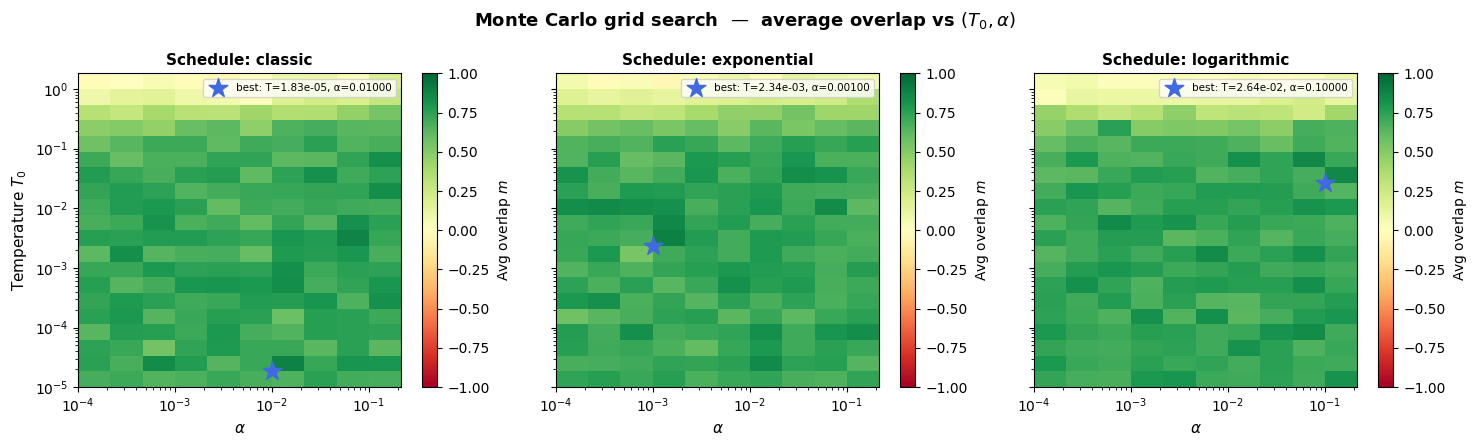


Best parameters:  {'temperature': np.float64(0.002335721469090121), 'alpha': np.float64(0.001), 'schedule': 'exponential'}
Best avg overlap: 0.8954


In [ ]:
shape = (14, 14)
n_patterns = 20
q = 0.7
N_REPEATS = 1      # increased from 1 for more reliable estimates

# Log-spaced grids covering physically relevant ranges:
# T0 : from 1e-5 (near-zero temperature) to 1.0 (high noise)
# alpha: decay rate — too large collapses T immediately, too small never cools
T_values = np.logspace(-5, 0, 20)   # 1e-5 to 1
alpha_values = np.logspace(-4, -1, 10)  # 1e-4 to 0.1
schedules = ['classic', 'exponential', 'logarithmic']

results_gs = {sched: np.zeros((len(T_values), len(alpha_values)))
              for sched in schedules}

for sched in schedules:
    print(f"Schedule: {sched} ...", end=" ", flush=True)
    for t_idx, T in enumerate(T_values):
        for a_idx, alpha in enumerate(alpha_values):
            overlaps = []
            for rep in range(N_REPEATS):
                pats = generate_random_patterns(shape, n_patterns, seed=SEED + rep)
                corr = corrupt_patterns(pats, q, method='random', seed=SEED + rep)
                m = hopfield_model_torch(pats, update_method='montecarlo',
                                            learning_rule='hebb', verbose=False)
                rec = m.correct_patterns(
                           np.array([c.reshape(shape) for c in corr]),
                           temperature=T, alpha=alpha, schedule=sched)
                for orig, r in zip(pats, rec):
                    overlaps.append(float(m.overlap(orig, r)))
            results_gs[sched][t_idx, a_idx] = np.mean(overlaps)
    print("done")

# plot heatmap
# pcolormesh expects x-coords for columns and y-coords for rows.
# data[t_idx, a_idx] -> row = T, col = alpha  ->  x-axis = alpha, y-axis = T.
# We therefore pass alpha_values as x-edges and T_values as y-edges directly.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

A_edges = np.concatenate([alpha_values, [alpha_values[-1] * alpha_values[-1] / alpha_values[-2]]])
T_edges = np.concatenate([T_values,     [T_values[-1]     * T_values[-1]     / T_values[-2]]])

for ax, sched in zip(axes, schedules):
    data = results_gs[sched]
    im = ax.pcolormesh(A_edges, T_edges, data,
                         cmap='RdYlGn', vmin=-1, vmax=1,
                         shading='flat')

    t_idx, a_idx = np.unravel_index(np.argmax(data), data.shape)
    ax.scatter(alpha_values[a_idx], T_values[t_idx],
               marker='*', s=200, color='royalblue', zorder=5,
               label=f'best: T={T_values[t_idx]:.2e}, α={alpha_values[a_idx]:.5f}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Schedule: {sched}', fontsize=11, fontweight='bold')
    ax.set_xlabel(r'$\alpha$', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Temperature $T_0$', fontsize=11)
    ax.legend(fontsize=7.5, loc='upper right')
    plt.colorbar(im, ax=ax, label='Avg overlap $m$')

fig.suptitle('Monte Carlo grid search  —  average overlap vs $(T_0, \\alpha)$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# best overall configuration 
best_ov = -np.inf
best_params = {}
for sched in schedules:
    t_idx, a_idx = np.unravel_index(np.argmax(results_gs[sched]), results_gs[sched].shape)
    ov = results_gs[sched][t_idx, a_idx]
    if ov > best_ov:
        best_ov = ov
        best_params = {'temperature': T_values[t_idx],
                       'alpha':       alpha_values[a_idx],
                       'schedule':    sched}

print(f"\nBest parameters:  {best_params}")
print(f"Best avg overlap: {best_ov:.4f}")

### Results

In [51]:
model_mc = hopfield_model_torch(patterns, update_method='montecarlo', learning_rule='hebb', verbose=True)
recovered_mc = model_mc.correct_patterns(np.array([c.reshape(shape) for c in corrupted]),temperature=0.0023357, alpha=0.001, schedule='exponential')

Converged after 7 iterations
Converged after 7 iterations
Converged after 6 iterations
Converged after 7 iterations
Converged after 11 iterations
Converged after 7 iterations
Converged after 7 iterations
Converged after 6 iterations
Converged after 11 iterations
Converged after 9 iterations
Converged after 6 iterations
Converged after 7 iterations
Converged after 9 iterations
Converged after 6 iterations
Converged after 13 iterations
Converged after 8 iterations
Converged after 8 iterations
Converged after 10 iterations
Converged after 5 iterations
Converged after 5 iterations


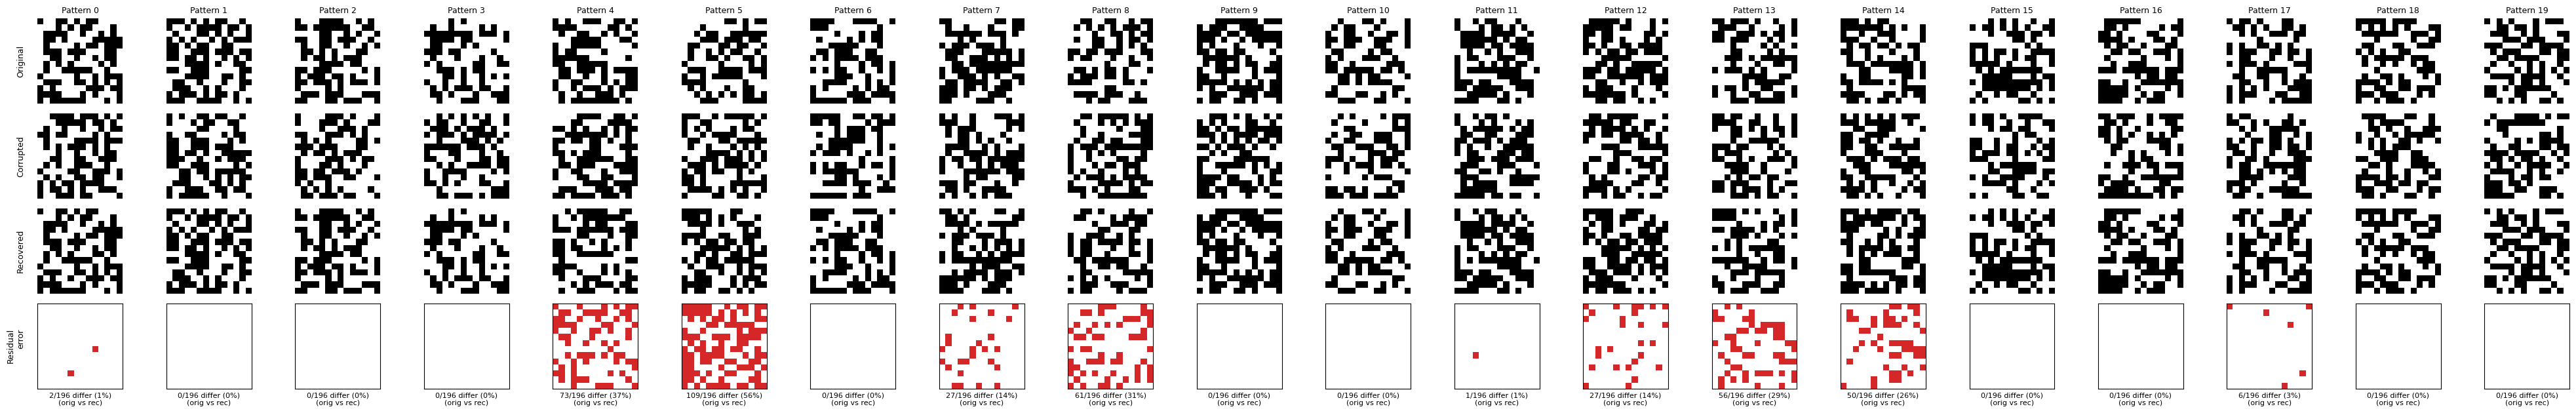

In [ ]:
plot_all_results(patterns, corrupted, recovered_mc, model=model_mc)

Recovery curves m(q) for three update methods, at three storage loads. We sweep q for each of P = 20, 25, 30 patterns on an N = 14×14 = 196 network, i.e. alpha = P/N = 0.10, 0.13, 0.15 — near the classical capacity alpha_c ≈ 0.138. Each panel shows synchronous, asynchronous and Monte Carlo overlay; the three methods are expected to collapse on each other, and the whole family of curves to drop as alpha increases.

P = 20  (alpha = 0.102) ... done
P = 25  (alpha = 0.128) ... done
P = 30  (alpha = 0.153) ... done


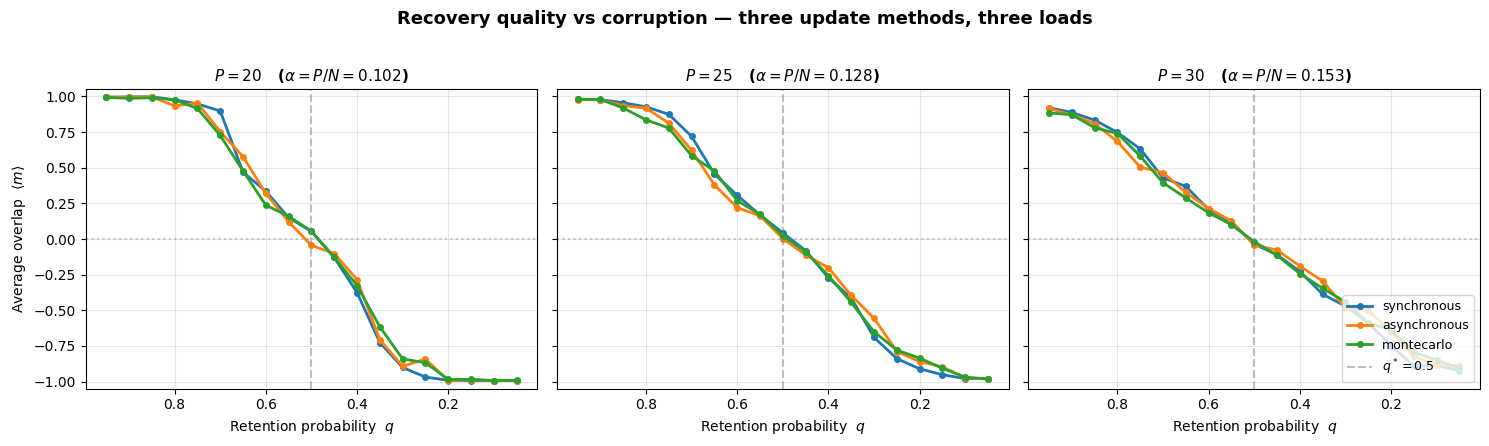

In [ ]:
shape = (14, 14)
N = shape[0] * shape[1]
P_values = [20, 25, 30]
q_values = np.linspace(0.95, 0.05, 19)
methods = ['synchronous', 'asynchronous', 'montecarlo']
colors = {'synchronous': 'C0', 'asynchronous': 'C1', 'montecarlo': 'C2'}

# MC annealing parameters reused from the previous grid search
mc_kw = {'temperature': best_params['temperature'],
         'alpha':       best_params['alpha'],
         'schedule':    best_params['schedule']}

# nested dict: curves[P][method] = list of <m> across q_values
curves = {P: {name: [] for name in methods} for P in P_values}

for P in P_values:
    print(f"P = {P}  (alpha = {P/N:.3f}) ...", end=" ", flush=True)
    for q in q_values:
        pats = generate_random_patterns(shape, P, seed=SEED)
        corr = corrupt_patterns(pats, q, method='random', seed=SEED)
        for name in methods:
            m = hopfield_model_torch(pats, update_method=name,
                                       learning_rule='hebb', verbose=False)
            kw = mc_kw if name == 'montecarlo' else {}
            rec = m.correct_patterns(
                      np.array([c.reshape(shape) for c in corr]), **kw)
            ov = np.mean([float(m.overlap(o, r)) for o, r in zip(pats, rec)])
            curves[P][name].append(ov)
    print("done")

# plot
fig, axes = plt.subplots(1, len(P_values), figsize=(5 * len(P_values), 4.5),
                          sharey=True)
for ax, P in zip(axes, P_values):
    for name in methods:
        ax.plot(q_values, curves[P][name], 'o-', color=colors[name],
                label=name, lw=2, ms=4)
    ax.axvline(0.5, ls='--', color='gray', alpha=0.5,
               label=r'$q^* = 0.5$')
    ax.axhline(0,   ls=':',  color='gray', alpha=0.4)
    ax.set_xlabel(r'Retention probability  $q$')
    ax.set_title(rf'$P = {P}$   ($\alpha = P/N = {P/N:.3f}$)',
                 fontsize=11, fontweight='bold')
    ax.set_ylim(-1.05, 1.05)
    ax.invert_xaxis()
    ax.grid(alpha=0.3)
axes[0].set_ylabel(r'Average overlap  $\langle m \rangle$')
axes[-1].legend(loc='lower right', fontsize=9)

fig.suptitle('Recovery quality vs corruption — three update methods, three loads',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The three update rules give nearly indistinguishable recovery curves in every
panel: synchronous, asynchronous and Monte Carlo overlap to within the
sampling noise across the whole $q$ range, at all three loads. This is not
a coincidence. The Monte Carlo run uses the best annealing parameters found
by the grid search, $T_0 \approx 2 \times 10^{-3}$ with exponential decay —
effectively zero temperature from the first sweep onward — so the MC update
degenerates to greedy asynchronous descent and the two coincide *by
construction*. The synchronous rule could in principle differ, since it can
fall into period-2 cycles that the asynchronous one cannot, but on
uncorrelated random patterns this does not happen often enough to leave a
visible trace in the mean overlap.

What does change visibly is the **storage load**. As $\alpha = P/N$ crosses
the classical capacity $\alpha_c \approx 0.138$, the curves flatten and the
clean retrieval plateau at high $q$ disappears: at $P = 20$ ($\alpha = 0.10$)
the network recovers near-perfectly down to $q \approx 0.8$, at $P = 25$
($\alpha = 0.13$) the high-$q$ plateau already sits below 1, and at $P = 30$
($\alpha = 0.15$, *above* $\alpha_c$) even noiseless inputs are no longer
attractors — the maximum overlap saturates below 0.9. The transition around
$q^* = 0.5$ also broadens: with many stored patterns interfering, the noise
threshold becomes a smooth crossover rather than a sharp step.

The takeaway is that **the update rule is not the bottleneck**: all three
methods are equivalent in this regime, and pushing past capacity requires
changing the *learning rule* or the *architecture* — which motivates the
Modern Hopfield Network examined in the next section.

---
<a id="6-part-d"></a>
## 6 — Part D: Storage capacity and pattern overlap

### 6.1 Overlap vs corruption level $q$

For fixed $N$ and $P$ we sweep $q$ from 0 to 1 and record the average
*overlap* between recovered and original patterns:

$$
m = \frac{1}{N}\sum_i S_i \xi_i \in [-1, 1]
$$

$m = 1$ means perfect retrieval; $m \approx 0$ means random output.  We
expect a **sharp transition** near a critical $q^*$: below $q^*$ the noise is
too large for reliable retrieval; above $q^*$ the network converges to the
correct attractor.


  P = 5 ... done
  P = 10 ... done
  P = 20 ... done
  P = 25 ... done
  P = 30 ... done
  P = 35 ... done


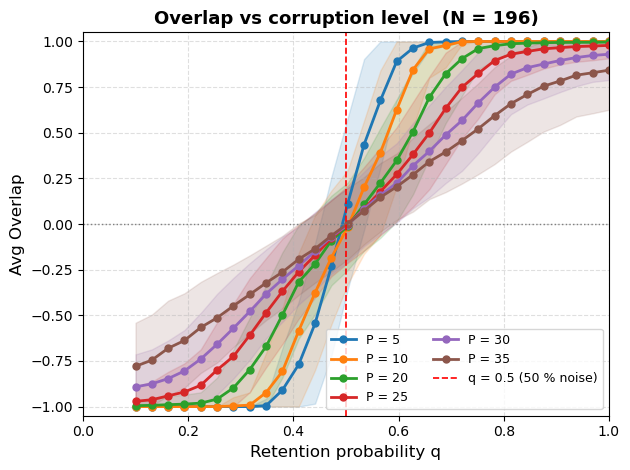

In [ ]:
os.makedirs('plots', exist_ok=True)

shape = (14, 14)
N = shape[0] * shape[1]
q_values = np.linspace(0.1, 1.0, 30)
P_values = [5, 10, 20, 25, 30, 35]
N_REPEATS = 20       # average over independent pattern sets

results_vs_q = {P: {} for P in P_values}

for P in P_values:
    print(f"  P = {P} ...", end=" ", flush=True)
    for q in q_values:
        overlaps = []
        for rep in range(N_REPEATS):
            pats = generate_random_patterns(shape, P, seed=SEED + rep)
            corr = corrupt_patterns(pats, q, method='random', seed=SEED + rep)
            m_rep = hopfield_model_torch(pats, update_method='synchronous',
                                         learning_rule='hebb', verbose=False)
            rec = m_rep.correct_patterns(
                        np.array([c.reshape(shape) for c in corr]))
            for orig, r in zip(pats, rec):
                overlaps.append(float(m_rep.overlap(orig, r)))
        results_vs_q[P][q] = (np.mean(overlaps), np.std(overlaps))
    print("done")

plot_overlap_vs_q(results_vs_q, P_values, N)

**Observation.** Each curve drops from $m \approx 1$ to $m \approx 0$ as $q$
decreases through a critical value $q^*$.  Larger $P$ shifts $q^*$ to higher
values — more patterns means the network is harder to fool but also more
fragile.  This is the analog of a **phase transition** between an ordered
(memory-retrieval) phase and a disordered (random) phase.


### 6.2 Overlap vs number of patterns $P$ — capacity analysis

Now we fix $q$ and increase $P$ until retrieval breaks down.  The theoretical
limit $P_c \approx 0.138\,N$ marks where the network becomes saturated.


  q = 0.90 ... done
  q = 0.80 ... done
  q = 0.70 ... done
  q = 0.60 ... done


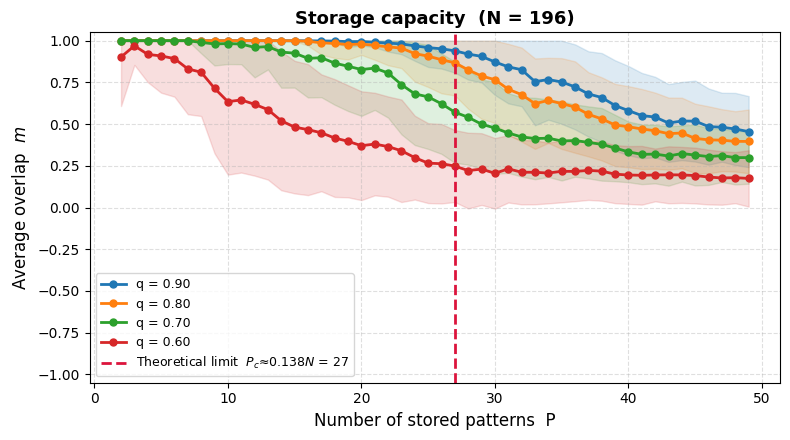

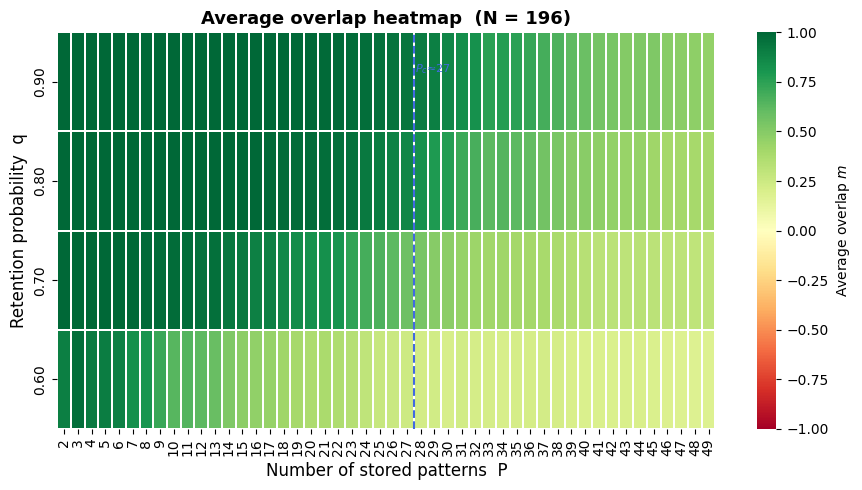

In [12]:
shape = (14, 14)
N = shape[0] * shape[1]
q_list = [0.9, 0.8, 0.7, 0.6]
# Extended to P=50 to clearly show the degradation beyond P_c ≈ 27 (= 0.138 × 196)
P_list = list(range(2, 50))

N_REPEATS = 5

results_vs_P = {q: {} for q in q_list}

for q in q_list:
    print(f"  q = {q:.2f} ...", end=" ", flush=True)
    for P in P_list:
        overlaps = []
        for rep in range(N_REPEATS):
            pats = generate_random_patterns(shape, P, seed=SEED + rep)
            corr = corrupt_patterns(pats, q, method='random', seed=SEED + rep)
            m = hopfield_model_torch(pats, update_method='synchronous',
                                        learning_rule='hebb', verbose=False)
            rec = m.correct_patterns(
                       np.array([c.reshape(shape) for c in corr]))
            for orig, r in zip(pats, rec):
                overlaps.append(float(m.overlap(orig, r)))
        results_vs_P[q][P] = (np.mean(overlaps), np.std(overlaps))
    print("done")

plot_overlap_vs_P(results_vs_P, q_list, N,)
plot_capacity_heatmap(results_vs_P, q_list, P_list, N,)
N_mhn = N   # alias used in MHN section

**Observation.** The overlap drops sharply near $P_c \approx 0.138N \approx 27$
for $N = 14^2 = 196$.  The transition is **sharper for lower noise** (high $q$):
with little corruption the network either retrieves perfectly or fails
completely.  With more noise the transition is softer because even a perfect
retrieval gives $m < 1$ for small $q$.

The heatmap condenses both sweeps: the blue dashed line marks $P_c$ and the
colour encodes $m$ from −1 (wrong attractor) to +1 (perfect retrieval).


### 6.3 Phase diagram in the $(T,\alpha)$ plane — Amit–Gutfreund–Sompolinsky

Sections 6.1–6.2 explored two one-dimensional slices of the network behaviour:
$m$ as a function of $q$ at fixed $P$, and $m$ as a function of $P$ at fixed $q$.
The full picture in equilibrium statistical mechanics is two-dimensional, with
axes **temperature** $T$ and **storage load** $\alpha = P/N$.

Here $T$ is a genuine thermodynamic temperature: rather than the deterministic
sign rule of the original 1982 model, we use a stochastic Glauber/Metropolis
update with flip probability $\propto e^{-\Delta E / T}$, so that the equilibrium
distribution of states is the Boltzmann measure $P(S) \propto e^{-E(S)/T}$. The
limit $T\to 0$ recovers the deterministic sign dynamics. The Monte Carlo machinery
of Section 5.3 already implements exactly this — we now use it with
`alpha_decay = 0` (so $T(t) = T_0$) **to sample equilibrium**, not to anneal.

Amit, Gutfreund and Sompolinsky (1985) showed that this equilibrium has three
phases:

| Phase | Description | Order parameter |
|---|---|---|
| **P** — paramagnetic | thermal noise wins; spins fluctuate freely | $m \approx 0$, $q_{\text{EA}} \approx 0$ |
| **R** — retrieval | one stored pattern is macroscopically aligned with the state | $m \approx 1$ |
| **SG** — spin glass | spins are frozen but not aligned with any stored pattern | $m \approx 0$, $q_{\text{EA}}>0$ |

Their mean-field analysis predicts:

- a **critical temperature** $T_c = 1$ at $\alpha = 0$, above which thermal
  noise melts all ordering (R and SG → P);
- a **critical load** $\alpha_c \approx 0.138$ at $T = 0$, above which the
  pattern states are no longer even local minima of the free energy (this is
  the same $P_c \approx 0.138\,N$ we hit in 6.2);
- a wedge-shaped R region in the lower-left of the $(T,\alpha)$ plane,
  bounded by SG to the right and P on top, with all three boundaries meeting
  at a triple point near $(T,\alpha) \approx (0.46, 0.138)$.

For each $(T,\alpha)$ we initialise the network *on* a stored pattern, let it
thermalise, then time-average the overlap with that pattern over the last sweeps.
Retrieval at equilibrium is the statement that this time-averaged $\langle m\rangle$
stays close to 1; loss of retrieval shows up as $\langle m\rangle \to 0$. This is
a finite-$N$ simulation — at $N \approx 200$ the phase boundaries are visibly
rounded compared with the sharp mean-field curves — but the qualitative structure
(retrieval wedge in the lower-left, melting at $T \approx 1$, collapse at
$\alpha \approx 0.14$) emerges clearly.

Phase diagram grid: 12 × 12 = 144 cells, 3 reps each.
  alpha = 0.020  (P=4) ... done  (   4.4s elapsed)
  alpha = 0.046  (P=9) ... done  (   8.2s elapsed)
  alpha = 0.071  (P=14) ... done  (  12.0s elapsed)
  alpha = 0.097  (P=19) ... done  (  15.9s elapsed)
  alpha = 0.122  (P=24) ... done  (  19.9s elapsed)
  alpha = 0.148  (P=29) ... done  (  23.7s elapsed)
  alpha = 0.173  (P=34) ... done  (  27.7s elapsed)
  alpha = 0.199  (P=39) ... done  (  39.8s elapsed)
  alpha = 0.224  (P=44) ... done  (  47.3s elapsed)
  alpha = 0.250  (P=49) ... done  (  51.4s elapsed)
  alpha = 0.276  (P=54) ... done  (  55.3s elapsed)
  alpha = 0.301  (P=59) ... done  (  59.5s elapsed)

Total time: 59.5s
Retrieval region (<m> > 0.5) covers 35.4% of the sampled (T,alpha) plane.


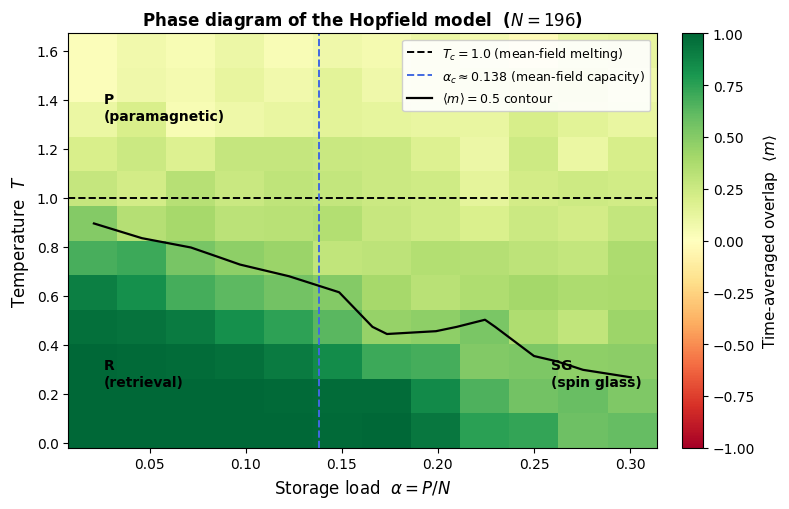

In [ ]:
results_pd = compute_phase_diagram(
    shape = (14, 14),
    T_values = np.linspace(0.05, 1.6, 12),
    alpha_values = np.linspace(0.02, 0.30, 12),
    n_reps=3, n_therm=3, n_measure=5, seed=SEED,
)
plot_phase_diagram(results_pd)

### Modern Hopfield Network — Part D extended

The classical analysis above shows a **hard capacity ceiling** at
$P_c \approx 0.138\,N$.  Here we ask: *what would change if we had used
the Modern Hopfield Network (MHN) instead?*

The MHN (Ramsauer et al., 2020) replaces the quadratic energy

$$H_\text{classic}[\mathbf{S}] = -\tfrac{1}{2}\mathbf{S}^\top J\,\mathbf{S}$$

with an **exponential** one:

$$H_\text{modern}[\mathbf{S}] =
  -\operatorname{lse}(\beta,\,X^\top\mathbf{S})
  + \tfrac{1}{2}\mathbf{S}^\top\mathbf{S} + \log Z$$

where $\operatorname{lse}(\beta,\mathbf{z}) = \frac{1}{\beta}\log\sum_\mu e^{\beta z_\mu}$
is the log-sum-exp function, $X=[\boldsymbol{\xi}^1|\cdots|\boldsymbol{\xi}^P]$
is the matrix of stored patterns, and $\beta$ is an inverse temperature.

Minimising $H_\text{modern}$ by gradient descent gives the **one-step update rule**:

$$\mathbf{S} \;\leftarrow\; X\,\operatorname{softmax}(\beta\,X^\top\mathbf{S})$$

This is a **weighted nearest-neighbour lookup** in pattern space, and it
converges in one or two steps for well-separated patterns.

| | Classical HN | Modern HN |
|---|---|---|
| Weight matrix $J$ | Required (Hebbian sum) | **Not needed** — patterns stored as-is |
| Update rule | $\operatorname{sign}(J\mathbf{S})$ | $X\,\operatorname{softmax}(\beta X^\top\mathbf{S})$ |
| Capacity | $P_c\approx 0.138N$ | $\sim 2^{N/2}$ (exponential in $N$) |
| Spurious states | Many | Almost none |
| Failure mode | Too many patterns ($P>P_c$) | Patterns **too similar** to each other |
| New hyper-parameter | — | $\beta$ (inverse temperature) |

In [40]:
# Modern Hopfield helper (no extra dependencies needed)

def mhn_retrieve(query, patterns, beta=8.0, max_iter=20, tol=1e-6):

    shape = query.shape
    X = np.stack([p.flatten() for p in patterns], axis=1).astype(np.float32)  # (N, P)
    s = query.flatten().astype(np.float32)

    for _ in range(max_iter):
        logits = beta * (X.T @ s)               # (P,)  — similarity scores
        logits -= logits.max()                  # numerical stability
        a = np.exp(logits); a /= a.sum()        # softmax weights over patterns
        s_new = X @ a                           # weighted combination
        if np.max(np.abs(s_new - s)) < tol:
            break
        s = s_new

    # Note: the MHN update rule converges to a *continuous* fixed point.
    # Binarising with np.sign at the end maps it back to the binary spin space
    # expected by the rest of the notebook.  This is a post-processing step,
    # not part of the continuous MHN dynamics.
    return np.sign(s).reshape(shape)   # binarise: continuous fixed point -> {+1,-1}


def mhn_overlap(original, recovered):
    #Same normalised overlap m = S·ξ / N used throughout the notebook.
    return float(np.dot(original.flatten(), recovered.flatten()) / original.size)


print("Modern Hopfield helpers loaded.")

BETA = 8.0   # default inverse temperature for MHN experiments

Modern Hopfield helpers loaded.


#### Continuous-state form and energy

The helper above binarises the final state through `np.sign(...)` for a
fair comparison with the classical $\{+1,-1\}$ model. The full MHN, however,
actually lives in **continuous** space — the fixed point
$\hat{\mathbf{S}} = X\,\text{softmax}(\beta\,X^\top\hat{\mathbf{S}})$ is a
real-valued vector in $\mathbb{R}^N$, not in $\{\pm1\}^N$. Exposing the
continuous version is useful for two reasons:

1. We can **evaluate the energy** $E_\text{mod}$ at intermediate steps
   and check that the iteration really is a descent on the modern
   landscape.
2. The continuous update rule
   $\mathbf{S}\!\leftarrow\!X\,\text{softmax}(\beta X^\top\mathbf{S})$
   is identical in form to a single self-attention head with
   $Q\!=\!\mathbf{S}^\top$ and $K\!=\!V\!=\!X^\top$.


In [9]:
# Continuous-state Modern Hopfield helpers
# Same iteration as `mhn_retrieve`, but without the final sign() step, plus
# the explicit energy used by Ramsauer et al. 2020 (Eq. 1, constants dropped).

def mhn_energy(s, patterns, beta=8.0):
    X = np.stack([p.flatten() for p in patterns], axis=1).astype(np.float32)
    s = s.flatten().astype(np.float32)
    z = beta * (X.T @ s)
    z_max = float(z.max())
    lse = z_max + np.log(np.exp(z - z_max).sum())     # numerically stable
    return float(-lse / beta + 0.5 * (s @ s))


def mhn_retrieve_continuous(query, patterns, beta=8.0, max_iter=20, tol=1e-6):
    # Continuous-state MHN fixed-point iteration.  Returns both the final state
    # and the full trajectory so we can plot the energy along the dynamics.
    shape = query.shape
    X = np.stack([p.flatten() for p in patterns], axis=1).astype(np.float32)
    s = query.flatten().astype(np.float32)
    traj = [s.copy()]
    for _ in range(max_iter):
        z = beta * (X.T @ s); z -= z.max()
        a = np.exp(z); a /= a.sum()
        s_new = X @ a
        traj.append(s_new.copy())
        if np.max(np.abs(s_new - s)) < tol:
            break
        s = s_new
    return s.reshape(shape), np.array(traj)


print("Continuous-state MHN helpers loaded.")

Continuous-state MHN helpers loaded.


#### Energy landscape — classical vs modern

To see why the modern model has more room to store patterns we visualise both energies on the same 2-D slice. Pick two stored patterns $\boldsymbol{\xi}^1,\boldsymbol{\xi}^2$ and parameterise the state as

$$
\mathbf{S}(\alpha,\gamma) \;=\; \alpha\,\boldsymbol{\xi}^1 + \gamma\,\boldsymbol{\xi}^2
,\qquad \alpha,\gamma\in[-1.5,\,1.5]
$$

so that the $(\alpha,\gamma)$-plane contains both attractors. Plotting $H_\text{classic}$ and $E_\text{mod}$ on this plane gives a direct picture of basin shape and separation.


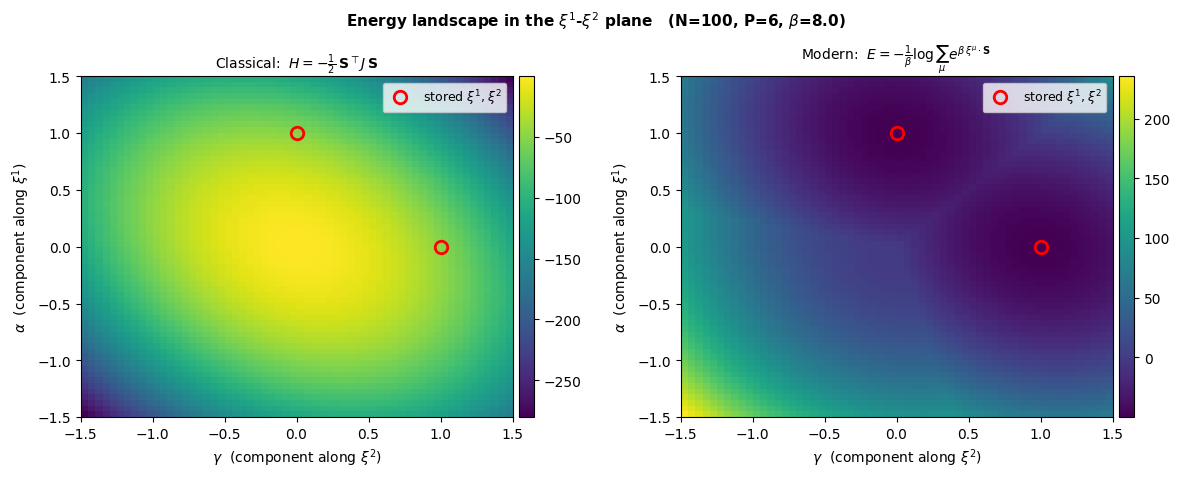

In [10]:
# 2-D slice of the energy landscape — classical vs modern
# Lower energy = darker.  The two stored patterns sit at the two minima.

shape_demo = (10, 10)
N_demo = shape_demo[0] * shape_demo[1]
P_demo = 6
pats_demo = generate_random_patterns(shape_demo, P_demo, seed=SEED)

xi1 = pats_demo[0].flatten().astype(np.float32)
xi2 = pats_demo[1].flatten().astype(np.float32)

# classical J (Hebbian, zero diagonal)
X_demo = np.stack([p.flatten() for p in pats_demo], axis=1).astype(np.float32)
J_demo = (X_demo @ X_demo.T) / N_demo
np.fill_diagonal(J_demo, 0.0)

def H_classic(s):
    return float(-0.5 * s @ J_demo @ s)

alphas = np.linspace(-1.5, 1.5, 60)
gammas = np.linspace(-1.5, 1.5, 60)
Hc = np.zeros((len(alphas), len(gammas)))
Hm = np.zeros((len(alphas), len(gammas)))
for i, a in enumerate(alphas):
    for j, g in enumerate(gammas):
        s = a * xi1 + g * xi2
        Hc[i, j] = H_classic(s)
        Hm[i, j] = mhn_energy(s.reshape(shape_demo), pats_demo, beta=BETA)

extent = [gammas[0], gammas[-1], alphas[0], alphas[-1]]

# (panel rectangle, colorbar rectangle, energy grid, title) in figure coords
fig = plt.figure(figsize=(12, 4.8))
specs = [
    ([0.07, 0.13, 0.36, 0.71], [0.435, 0.13, 0.013, 0.71], Hc,
     r'Classical:  $H = -\frac{1}{2}\,\mathbf{S}^\top J\,\mathbf{S}$'),
    ([0.57, 0.13, 0.36, 0.71], [0.935, 0.13, 0.013, 0.71], Hm,
     r'Modern:  $E = -\frac{1}{\beta}\log\sum_\mu e^{\beta\,\xi^\mu\cdot\mathbf{S}}$'),
]
for ax_pos, cax_pos, Z, title in specs:
    ax = fig.add_axes(ax_pos)
    cax = fig.add_axes(cax_pos)
    im = ax.imshow(Z, origin='lower', extent=extent, aspect='auto', cmap='viridis')
    # mark the two stored patterns at (gamma, alpha) = (0, 1) and (1, 0)
    ax.plot([0, 1], [1, 0], 'o', color='red', ms=9, mfc='none', mew=2,
            label=r'stored $\xi^1,\xi^2$')
    ax.set_xlabel(r'$\gamma$  (component along $\xi^2$)', fontsize=10)
    ax.set_ylabel(r'$\alpha$  (component along $\xi^1$)', fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9, loc='upper right')
    fig.colorbar(im, cax=cax)

suptitle = (r'Energy landscape in the $\xi^1$-$\xi^2$ plane'
            + f'   (N={N_demo}, P={P_demo}, ' + r'$\beta$' + f'={BETA})')
fig.suptitle(suptitle, fontsize=11, fontweight='bold')
plt.show()

**Observation.**
Both landscapes have minima at $(\alpha,\gamma)=(1,0)$ and $(0,1)$ — i.e.
on the two stored patterns.  But the *shapes* are very different.

- The classical $H$ is a smooth quadratic. The wells around the stored
  patterns are broad and shallow, and the cross-direction
  $(\alpha,\gamma)\!\approx\!(1,1)$ is not strongly disfavoured. This is
  exactly the geometric source of the *spurious minima* (mixtures of
  stored patterns) that plague the Hebbian rule near capacity.
- The modern $E$ is dominated by the log-sum-exp term. Outside a narrow
  region around each stored pattern the energy is essentially flat, while
  inside the basin it drops exponentially with $\beta$. The "ridge"
  between the two basins is sharp, so mixed states are strongly
  suppressed.

The capacity gap is therefore geometric: many sharp wells fit into the
same configuration space, while many shallow quadratic wells overlap and
merge.


---
#### MHN — Part D: capacity and distinguishability

This is where the two models differ **most dramatically**.

In the classical model the bottleneck is the number of patterns $P$:
once $P > P_c \approx 0.138N$ the weight matrix $J$ becomes saturated and
patterns interfere with each other.

In the MHN the bottleneck is **pattern similarity**.  As long as two
patterns are not nearly identical the softmax can distinguish them,
regardless of how many other patterns are stored.  The critical quantity
is the pairwise overlap
$$m_{\mu\nu} = \frac{1}{N}\boldsymbol{\xi}^\mu\cdot\boldsymbol{\xi}^\nu$$
not the total number $P$.

We run **three experiments** to show this concretely.

  q = 0.90 ... done
  q = 0.80 ... done
  q = 0.70 ... done
  q = 0.60 ... done


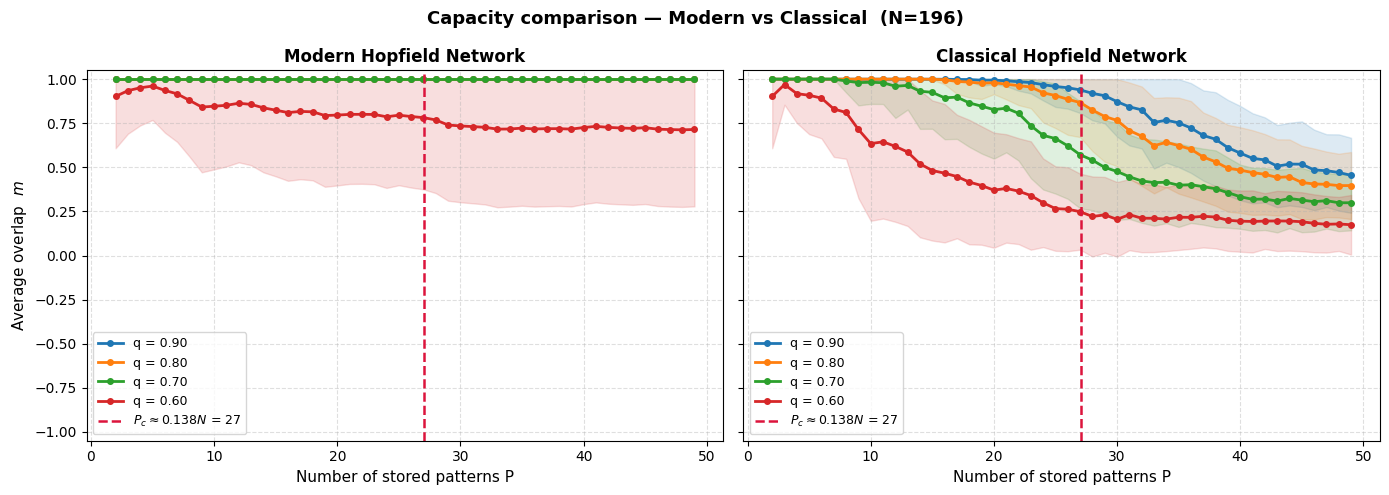

In [13]:
# Experiment 1: overlap vs P 
# We reuse shape=(14,14), N=196, q_list, P_list, N_REPEATS from Part D.

results_mhn_vs_P = {q: {} for q in q_list}
results_cls_vs_P = {q: {} for q in q_list}

for q in q_list:
    print(f"  q = {q:.2f} ...", end=" ", flush=True)
    for P in P_list:
        ov_mhn, ov_cls = [], []
        for rep in range(N_REPEATS):
            pats = generate_random_patterns(shape, P, seed=SEED + rep)
            corr = corrupt_patterns(pats, q, method='random', seed=SEED + rep)
            m_cls = hopfield_model_torch(pats, update_method='synchronous',
                                        learning_rule='hebb', verbose=False)
            for orig, c in zip(pats, corr):
                rec_m = mhn_retrieve(c, pats, beta=BETA)
                rec_c = m_cls.correct(c, max_iter=50).reshape(shape)
                ov_mhn.append(mhn_overlap(orig, rec_m))
                ov_cls.append(float(m_cls.overlap(orig, rec_c)))
        results_mhn_vs_P[q][P] = (np.mean(ov_mhn), np.std(ov_mhn))
        results_cls_vs_P[q][P] = (np.mean(ov_cls), np.std(ov_cls))
    print("done")

# Plot: overlap vs P, both models, one panel per q
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
classical_limit = 0.138 * N_mhn

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
titles = ['Modern Hopfield Network', 'Classical Hopfield Network']
results_list = [results_mhn_vs_P, results_cls_vs_P]

for ax, res, title in zip(axes, results_list, titles):
    for i, q in enumerate(q_list):
        color = PALETTE[i % len(PALETTE)]
        Ps = sorted(res[q].keys())
        avgs = np.array([res[q][P][0] for P in Ps])
        stds = np.array([res[q][P][1] for P in Ps])
        ax.plot(Ps, avgs, marker='o', markersize=4, lw=2,
                color=color, label=f'q = {q:.2f}')
        ax.fill_between(Ps,
                        np.clip(avgs - stds, -1, 1),
                        np.clip(avgs + stds, -1, 1),
                        color=color, alpha=0.15)
    ax.axvline(classical_limit, color='crimson', ls='--', lw=1.8,
               label=f'$P_c \\approx 0.138N$ = {classical_limit:.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of stored patterns P', fontsize=11)
    ax.set_ylim(-1.05, 1.05)
    ax.grid(True, ls='--', alpha=0.4)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Average overlap  $m$', fontsize=11)
fig.suptitle(f'Capacity comparison — Modern vs Classical  (N={N_mhn})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation.**
The classical model degrades sharply past $P_c \approx 27$, as seen in
Part D.  The MHN maintains $m \approx 1$ well beyond that limit because
the softmax lookup is not affected by the number of patterns — only by
how different they are from each other.

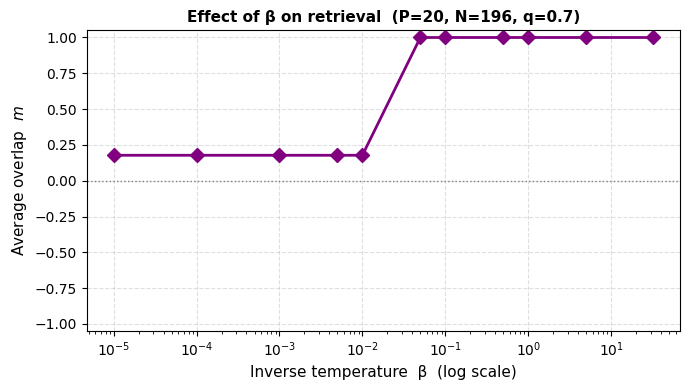

In [28]:
# Experiment 2: role of β — the key MHN hyper-parameter
# β controls how "sharp" the softmax is:
# β -> infinity : hard argmax (nearest-neighbour lookup)
# β -> 0 : uniform average over all patterns -> useless retrieval

P_beta = 20          # well above the classical limit
q_beta = 0.7
beta_values = [0.00001, 0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 32]
N_REPS_beta = 5

beta_avgs = []
for b in beta_values:
    ovs = []
    for rep in range(N_REPS_beta):
        pats = generate_random_patterns(shape, P_beta, seed=SEED + rep)
        corr = corrupt_patterns(pats, q_beta, method='random', seed=rep)
        for orig, c in zip(pats, corr):
            ovs.append(mhn_overlap(orig, mhn_retrieve(c, pats, beta=b)))
    beta_avgs.append(np.mean(ovs))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(beta_values, beta_avgs, 'D-', color='purple', lw=2, ms=7)
ax.set_xscale('log')
ax.axhline(0, color='grey', ls=':', lw=1)
ax.set_xlabel('Inverse temperature  β  (log scale)', fontsize=11)
ax.set_ylabel('Average overlap  $m$', fontsize=11)
ax.set_title(f'Effect of β on retrieval  (P={P_beta}, N={N_mhn}, q={q_beta})',
             fontsize=11, fontweight='bold')
ax.set_ylim(-1.05, 1.05)
ax.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Observation.**
$\beta$ plays the role of an **inverse temperature** and the curve traces
the paramagnetic→retrieval transition.

- For $\beta \lesssim 10^{-2}$ the softmax weights are nearly uniform, the
  retrieved state is essentially the average of the $P=20$ stored patterns,
  and the overlap sits at the random baseline $m \approx 1/\sqrt{P} \approx 0.22$.
- Around $\beta \sim 1/N \approx 5\cdot 10^{-3}$ the softmax starts
  concentrating on the closest pattern and $m$ rises.
- For $\beta \gtrsim 10^{-1}$ retrieval has saturated at $m \approx 1$.
  The ceiling is set by the noise itself ($q = 0.7$ flips 30 % of the
  pixels): even a perfect winner-take-all returns the correct pattern, but
  the *measured* overlap is dominated by the residual noise on the recovered
  state. There is no "brittle at large $\beta$" regime — once above
  threshold, every $\beta$ in this range gives the same answer.

So the relevant feature is a **threshold**, not an interior optimum: the
softmax either resolves the patterns or it does not.

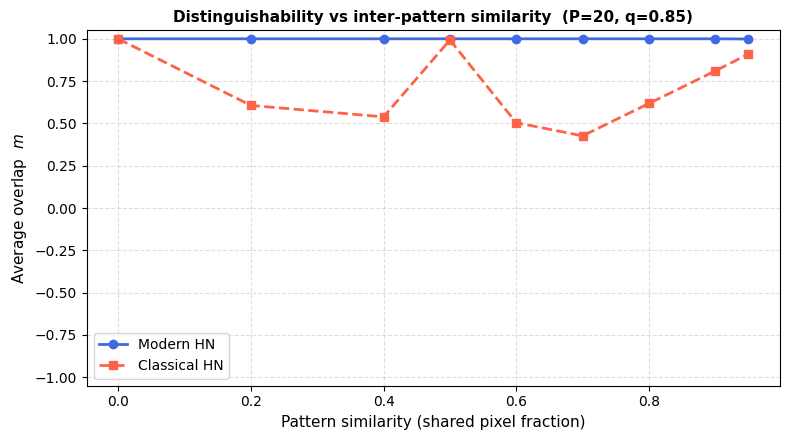

In [ ]:
# Experiment 3: pattern similarity is the real limit in the MHN
# We generate patterns with a controlled pairwise overlap and measure retrieval.
# High similarity -> softmax cannot distinguish -> retrieval fails.

def make_similar_patterns(base, n_patterns, similarity, rng_local):
    """
    Return n_patterns patterns each sharing `similarity` fraction
    of their pixels with `base`  (similarity=1 -> identical copy).
    """
    pats = [base.copy()]
    for _ in range(n_patterns - 1):
        p = base.copy()
        mask = rng_local.random(p.shape) > similarity   # flip (1-sim) fraction
        p[mask] *= -1
        pats.append(p)
    return pats


sim_values = [0.0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
P_sim = 20
q_sim = 0.85
N_REPS_sim = 5
rng_sim = np.random.default_rng(SEED + 77)
base_pat = generate_random_patterns(shape, 1, seed=SEED)[0]

mhn_sim_avgs, cls_sim_avgs = [], []
for sim in sim_values:
    ov_mhn, ov_cls = [], []
    for rep in range(N_REPS_sim):
        sim_pats = make_similar_patterns(base_pat, P_sim, sim,
                                          np.random.default_rng(SEED + rep))
        sim_corr = corrupt_patterns(sim_pats, q_sim, method='random', seed=rep)
        m_cls_sim = hopfield_model_torch(sim_pats, update_method='synchronous',
                                         learning_rule='hebb', verbose=False)
        for orig, c in zip(sim_pats, sim_corr):
            ov_mhn.append(mhn_overlap(orig, mhn_retrieve(c, sim_pats, beta=BETA)))
            ov_cls.append(float(m_cls_sim.overlap(orig,
                               m_cls_sim.correct(c, max_iter=50).reshape(shape))))
    mhn_sim_avgs.append(np.mean(ov_mhn))
    cls_sim_avgs.append(np.mean(ov_cls))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sim_values, mhn_sim_avgs, 'o-', color='royalblue', lw=2, label='Modern HN')
ax.plot(sim_values, cls_sim_avgs, 's--', color='tomato',   lw=2, label='Classical HN')
ax.set_xlabel('Pattern similarity (shared pixel fraction)', fontsize=11)
ax.set_ylabel('Average overlap  $m$', fontsize=11)
ax.set_title(f'Distinguishability vs inter-pattern similarity  (P={P_sim}, q={q_sim})',
             fontsize=11, fontweight='bold')
ax.set_ylim(-1.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Observation.**
In this regime ($P=5$, $\beta=8$, $q=0.85$, $N=196$), the MHN retrieves
perfectly across the entire similarity range, including $s = 0.95$ where
patterns share 95% of their pixels. Pushing the MHN past its similarity limit
would require either many more patterns (so several near-targets sum up
inside the softmax) or a $\beta$ closer to the critical threshold of
Experiment 2.

The classical curve, by contrast, fluctuates above 0.45 across similarity levels.

#### Energy trace along the MHN dynamics

The classical sign rule converges quickly in the $P\!\ll\!P_c$ regime,
and the energy trace from Section 5.2 confirms this. Does the MHN
dynamics show the same behaviour? Below we run the **continuous** MHN
update from a corrupted start and record the modern energy at every
iteration, alongside the classical energy trace from the sign rule on
the *same* starting point.


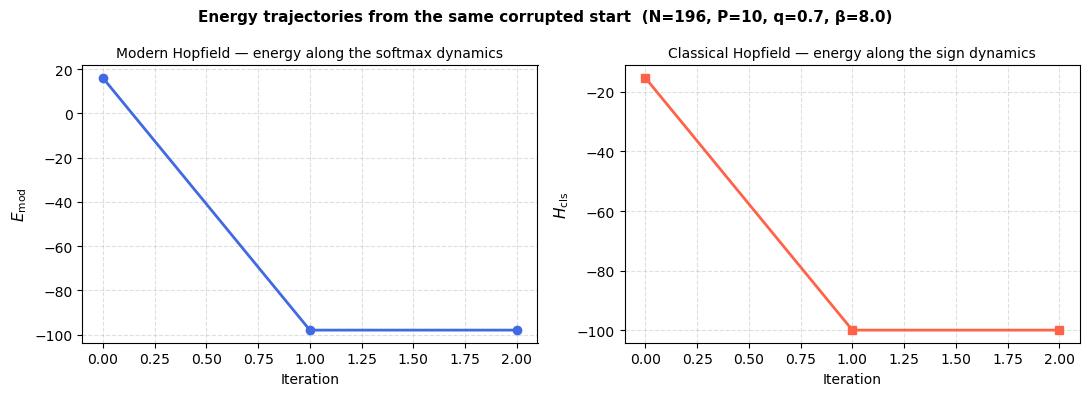

MHN reached its fixed point in 2 steps (ΔE_last = +0.000e+00)
Classical reached its fixed point in 2 steps


In [22]:
# Energy trace along the MHN dynamics 
shape_e = (14, 14)
P_e = 10
q_e = 0.7

pats_e = generate_random_patterns(shape_e, P_e, seed=SEED)
corr_e = corrupt_patterns(pats_e, q_e, method='random', seed=SEED)[0]

# Modern: continuous trajectory + energy at every iteration
_, traj    = mhn_retrieve_continuous(corr_e, pats_e, beta=BETA, max_iter=15)
E_traj_mhn = [mhn_energy(s.reshape(shape_e), pats_e, beta=BETA) for s in traj]

# Classical: replay the sign update by hand to extract H at every step
model_e = hopfield_model_torch(pats_e, update_method='synchronous',
                               learning_rule='hebb', verbose=False)
J_e = model_e.J.cpu().numpy().astype(np.float32)
s_cls = corr_e.flatten().astype(np.float32)
E_traj_cls = [-0.5 * float(s_cls @ J_e @ s_cls)]
for _ in range(15):
    s_next = np.sign(J_e @ s_cls)
    s_next[s_next == 0] = 1.0
    if np.array_equal(s_next, s_cls):           # fixed point reached
        E_traj_cls.append(E_traj_cls[-1])
        break
    s_cls = s_next
    E_traj_cls.append(-0.5 * float(s_cls @ J_e @ s_cls))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(len(E_traj_mhn)), E_traj_mhn, 'o-',
             color='royalblue', lw=2)
axes[0].set_xlabel('Iteration', fontsize=10)
axes[0].set_ylabel(r'$E_\mathrm{mod}$', fontsize=11)
axes[0].set_title('Modern Hopfield — energy along the softmax dynamics',
                  fontsize=10)
axes[0].grid(True, ls='--', alpha=0.4)

axes[1].plot(range(len(E_traj_cls)), E_traj_cls, 's-',
             color='tomato', lw=2)
axes[1].set_xlabel('Iteration', fontsize=10)
axes[1].set_ylabel(r'$H_\mathrm{cls}$', fontsize=11)
axes[1].set_title('Classical Hopfield — energy along the sign dynamics',
                  fontsize=10)
axes[1].grid(True, ls='--', alpha=0.4)

plt.suptitle(f'Energy trajectories from the same corrupted start  '
             f'(N={shape_e[0]*shape_e[1]}, P={P_e}, q={q_e}, β={BETA})',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/mhn_vs_classical_energy_trace.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"MHN reached its fixed point in {len(E_traj_mhn) - 1} steps "
      f"(ΔE_last = {E_traj_mhn[-1] - E_traj_mhn[-2]:+.3e})")
print(f"Classical reached its fixed point in {len(E_traj_cls) - 1} steps")

**Observation.**
The MHN energy drops sharply in the *first* iteration and is essentially
flat afterwards — the softmax has already concentrated almost all of its
weight on the correct stored pattern. The classical sign dynamics also
converges quickly here ($P=10\!\ll\!P_c$), but its per-step decrease is
quantised in units set by the spectrum of $J$, whereas the MHN decrease
is smooth (the dynamics lives in continuous space and only becomes
binary at the very end, when we apply `sign`). For larger $P$, closer
to $P_c$, the classical descent slows down considerably while the MHN
keeps its one-shot character; this is the practical face of the capacity
argument made earlier.


---
<a id="7-mnist"></a>
## 7 — MNIST digit prototypes

### 7.1 Motivation: why averaging at native resolution fails

The MNIST images are 28×28 pixels.  Each digit class contains ~6 000 training
images with slight shifts, rotations and stroke variations.  When we binarise
each image individually and take the **majority vote** per pixel, isolated
pixels that are +1 in only a few images but −1 in the rest produce *holes*
in the prototype.

We demonstrate this effect and then show that **upscaling before binarisation**
fills the holes: by working at higher resolution the local average is smoother
and the subsequent sign operation produces cleaner prototypes.


Loading MNIST (N=28, mode=majority_vote, upscale=1×) …
  Done. Counts per class: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}
Loading MNIST (N=28, mode=majority_vote, upscale=4×) …
  Done. Counts per class: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


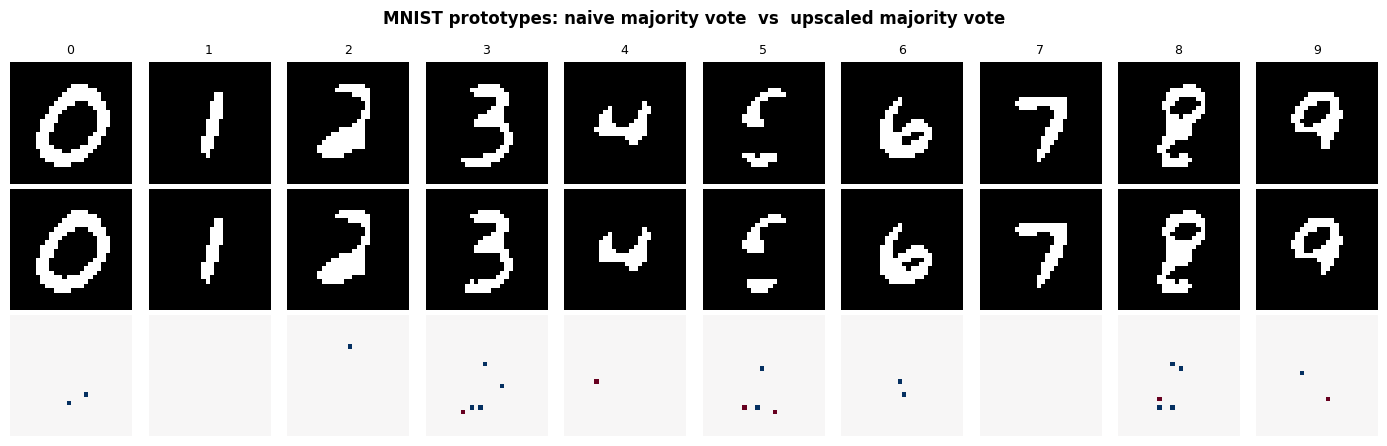

Naive        — avg fraction of −1 pixels: 0.900
Upscaled×4   — avg fraction of −1 pixels: 0.899
CPU times: user 1min 30s, sys: 1.39 s, total: 1min 32s
Wall time: 1min 34s


In [ ]:
%%time
# naive majority-vote prototype at native 28×28 
prototypes_naive = get_mnist_patterns(N=28, mode='majority_vote',
                                      upscale_factor=1, verbose=True)

# upscaled prototype: binarise at 28×4=112 px, then pool back to 28 
prototypes_up = get_mnist_patterns(N=28, mode='majority_vote',
                                      upscale_factor=4, verbose=True)

# comparison
fig, axes = plt.subplots(3, 10, figsize=(14, 4.5))
for d in range(10):
    # naive
    axes[0, d].imshow((prototypes_naive[d] + 1) / 2, cmap='gray', vmin=0, vmax=1)
    axes[0, d].set_title(str(d), fontsize=9)
    axes[0, d].axis('off')
    # upscaled
    axes[1, d].imshow((prototypes_up[d]    + 1) / 2, cmap='gray', vmin=0, vmax=1)
    axes[1, d].axis('off')
    # difference map
    diff = prototypes_naive[d] - prototypes_up[d]
    axes[2, d].imshow(diff, cmap='RdBu_r', vmin=-2, vmax=2)
    axes[2, d].axis('off')

    axes[0, 0].set_ylabel('Naive(28×28)', fontsize=8)
    axes[1, 0].set_ylabel('Upscaled(×4)', fontsize=8)
    axes[2, 0].set_ylabel('Difference', fontsize=8)

fig.suptitle('MNIST prototypes: naive majority vote  vs  upscaled majority vote',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# quantify hole density
for label, protos in [('Naive', prototypes_naive), ('Upscaled×4', prototypes_up)]:
    n_isolated = sum(
        int(np.sum(np.abs(np.diff(p, axis=0)).sum() + np.abs(np.diff(p, axis=1)).sum()) > 0)
        for p in protos)
    avg_neg = np.mean([np.mean(p == -1) for p in protos])
    print(f"{label:12s} — avg fraction of −1 pixels: {avg_neg:.3f}")

The **difference map** (bottom row) highlights pixels that changed sign between
the two methods.  With naive majority vote, isolated hot pixels appear in regions
that are consistently +1 across all training images, simply because of small
mis-alignments.  The upscaled prototype is smoother and more faithful to the
perceived digit shape.


### 7.2 Storing all 10 digit prototypes

We use the upscaled prototypes as the $P = 10$ patterns to store.  Because
the 10 digits share structural features (e.g. digits 3 and 8 both have curved
strokes on the right), the **interference** between stored patterns is high —
a harder test than random patterns.


Interference between MNIST patterns:  0.7379
Theoretical limit P_c:               108.2
  (P = 10, so within capacity)


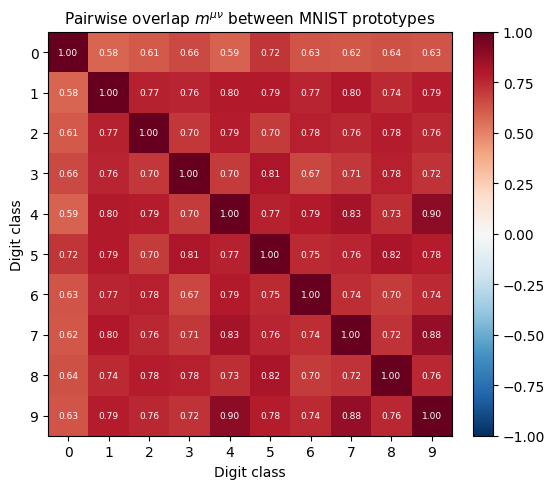

In [ ]:
# Use the upscaled prototypes
patterns_mnist = prototypes_up   # list of 10 arrays, shape (28, 28)

model_mnist = hopfield_model_torch(
    patterns_mnist,
    update_method='synchronous',
    learning_rule='local',
    R=4,
    verbose=False,
)
print(f"Interference between MNIST patterns:  {float(model_mnist.memory_interference()):.4f}")
print(f"Theoretical limit P_c:               {model_mnist.storage_limit():.1f}")
print(f"  (P = 10, so {'within' if 10 <= model_mnist.storage_limit() else 'ABOVE'} capacity)")

# Pairwise overlap matrix
P = len(patterns_mnist)
N_mnist = patterns_mnist[0].size
M = np.zeros((P, P))
for i in range(P):
    for j in range(P):
        M[i, j] = np.dot(patterns_mnist[i].flatten(),
                         patterns_mnist[j].flatten()) / N_mnist

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(P)); ax.set_yticks(range(P))
ax.set_xticklabels(range(P)); ax.set_yticklabels(range(P))
ax.set_xlabel('Digit class'); ax.set_ylabel('Digit class')
ax.set_title(r'Pairwise overlap $m^{\mu \nu}$ between MNIST prototypes', fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i in range(P):
    for j in range(P):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=6.5,
                color='white' if abs(M[i,j]) > 0.5 else 'black')
plt.tight_layout()
plt.show()

**Why is the interference so high?** The value $I = 0.74$ may seem anomalous
for only $P = 10$ patterns with $N = 784$ neurons (well below $P_c \approx 108$).
The cause is geometric: all prototypes share the same black background — the
vast majority of the $N$ pixels are $-1$ in every digit. The pairwise overlap
between any two prototypes is therefore dominated by this common background,
regardless of how visually distinct the digits are.

A direct consequence: the overlap metric $m = \frac{1}{N}\sum_i S_i \xi_i$
does not reliably distinguish between "the correct pattern was retrieved" and
"the network settled into a spurious minimum that shares many background pixels
with the target". This explains why visual recovery appears unreliable even
when $m$ looks acceptable.

A straightforward remedy would be to **centre the patterns** by subtracting
their mean before storage ($\tilde{\xi}_i^\mu = \xi_i^\mu - \bar{\xi}^\mu$),
reducing the background contribution to the overlap.

The diagonal is 1 by definition.  Large off-diagonal values (e.g. between
digits 3 & 8, or 4 & 9) signal high interference — these pairs will be the
hardest to distinguish.


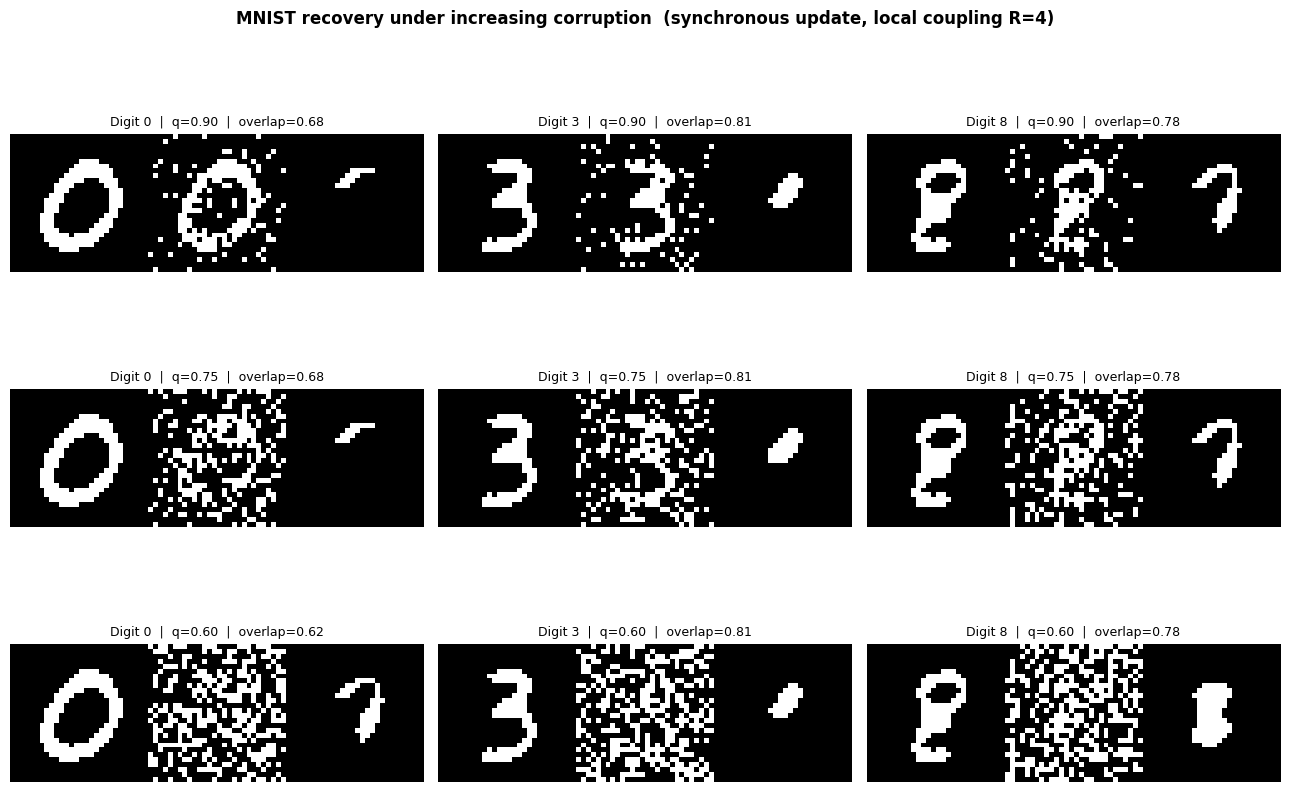

In [ ]:
# recovery at different corruption levels
fig, big_axes = plt.subplots(3, 3, figsize=(13, 9))
q_tests = [0.9, 0.75, 0.6]

for ax_row, q_val in zip(big_axes, q_tests):
    corrupted_m = corrupt_patterns(patterns_mnist, q_val, method='random', seed=SEED)
    recovered_m = model_mnist.correct_patterns(
        np.array([c.reshape(28, 28) for c in corrupted_m]),
        max_iter=200)

    # show 3 example digits per q level (0, 3, 8 — the tricky ones)
    for ax, digit_idx in zip(ax_row, [0, 3, 8]):
        orig_img = (patterns_mnist[digit_idx] + 1) / 2
        corr_img = (corrupted_m[digit_idx].reshape(28, 28) + 1) / 2
        rec_img = (recovered_m[digit_idx] + 1) / 2
        ov = float(model_mnist.overlap(patterns_mnist[digit_idx],
                                        recovered_m[digit_idx]))

        composite = np.concatenate([orig_img, corr_img, rec_img], axis=1)
        ax.imshow(composite, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Digit {digit_idx}  |  q={q_val:.2f}  |  overlap={ov:.2f}',
                     fontsize=9)
        ax.set_xlabel('original       corrupted       recovered', fontsize=7)
        ax.axis('off')

plt.suptitle('MNIST recovery under increasing corruption  '
             '(synchronous update, local coupling R=4)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Generalisation test: real instances vs prototypes**

We probe a question the previous cells do not answer: can the network, trained
on the 10 prototypes, **clean a real test-set instance toward its prototype**?
For each class $d$ we pick one MNIST test image, binarise it with the same
threshold used for the prototypes, and run the synchronous dynamics — first
without extra noise (intrinsic intra-class variability only), then at $q=0.75$.
All overlaps are measured against the **prototype** $\bar{\xi}^d$, not against
the instance itself.

/tmp/ipykernel_11293/2875983018.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


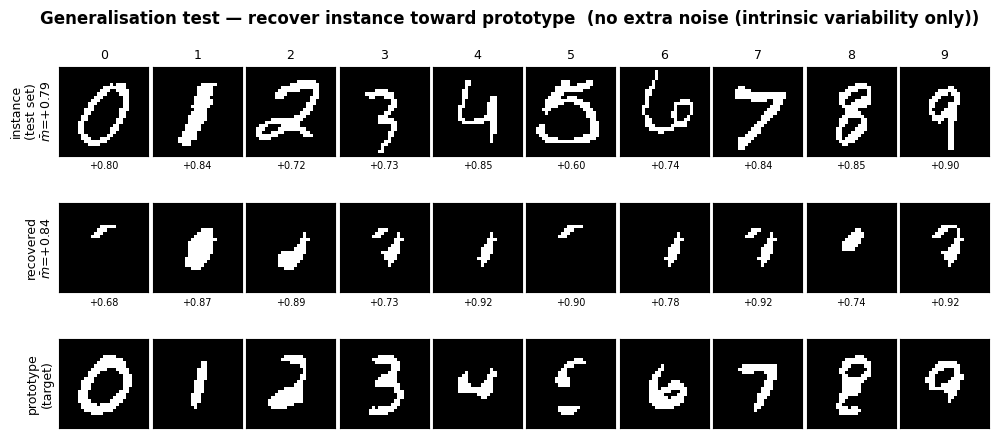

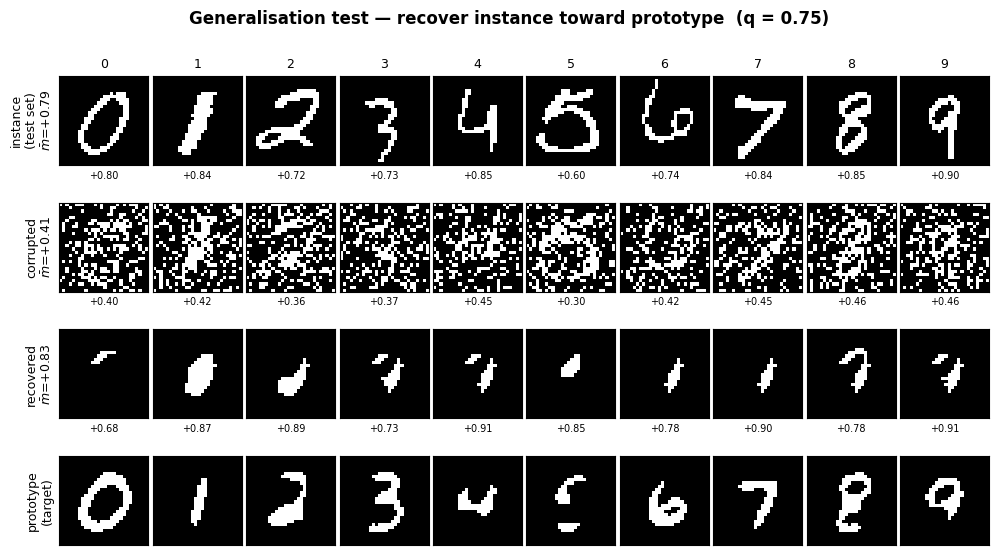

In [ ]:
# Generalisation test: corrupt a real MNIST instance, recover toward its prototype
from torchvision import datasets, transforms

# MNIST test set — never used to build the prototypes
test_set = datasets.MNIST(root='./mnist_data', train=False, download=True,
                          transform=transforms.ToTensor())
imgs_all = test_set.data.numpy().astype(np.float32) / 255.0   # (10000, 28, 28)
labels_all = test_set.targets.numpy()

# Pick one random instance per class, binarise with the same threshold
# used by the prototypes
rng = np.random.default_rng(SEED)
instances = []
for d in range(10):
    idx = rng.choice(np.where(labels_all == d)[0])
    instances.append(np.where(imgs_all[idx] > 0.5, 1.0, -1.0).astype(np.float32))
instances = np.array(instances)   # (10, 28, 28)

# Intrinsic overlap of each instance with its prototype (no artificial noise)
ov_intrinsic = [float(model_mnist.overlap(patterns_mnist[d], instances[d]))
                for d in range(10)]

# Two scenarios: pure generalisation (q=1) and moderate corruption (q=0.75)
for q_val in [1.0, 0.75]:
    corr_inst = corrupt_patterns(list(instances), q_val, method='random', seed=SEED)
    corr_arr = np.array([c.reshape(28, 28) for c in corr_inst])
    rec = model_mnist.correct_patterns(corr_arr, max_iter=200)

    # All overlaps are measured against the prototype, not the instance
    ov_corr = [float(model_mnist.overlap(patterns_mnist[d], corr_arr[d]))
               for d in range(10)]
    ov_rec = [float(model_mnist.overlap(patterns_mnist[d], rec[d]))
               for d in range(10)]

    # build rows (skip 'corrupted' at q=1.0 — would be identical to 'instance')
    rows = [('instance\n(test set)', instances, ov_intrinsic)]
    if q_val < 1.0:
        rows.append(('corrupted', corr_arr, ov_corr))
    rows.append(('recovered', rec, ov_rec))
    rows.append(('prototype\n(target)', patterns_mnist, None))

    fig, axes = plt.subplots(len(rows), 10,
                             figsize=(12, 1.3 * len(rows) + 1),
                             gridspec_kw={'wspace': 0.05, 'hspace': 0.30})
    for r, (label, imgs, ovs) in enumerate(rows):
        for d in range(10):
            ax = axes[r, d]
            ax.imshow((np.asarray(imgs[d]) + 1) / 2, cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if ovs is not None:
                ax.set_xlabel(f'{ovs[d]:+.2f}', fontsize=7)
            if r == 0:
                ax.set_title(str(d), fontsize=9)
        avg_str = f'\n$\\bar m$={np.mean(ovs):+.2f}' if ovs is not None else ''
        axes[r, 0].set_ylabel(label + avg_str, fontsize=9)

    title_q = ('no extra noise (intrinsic variability only)' if q_val == 1.0
               else f'q = {q_val:.2f}')
    fig.suptitle('Generalisation test — recover instance toward prototype  '
                 f'({title_q})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

**Result — a clean failure mode.** The dynamics converges in 5–15 steps, but
on a handful of **spurious states** (mixture minima of the Hebbian energy)
that look nothing like the digits: one elongated stroke and one central blob,
recurring across columns. Yet the average overlap $\bar m$ *increases* from
0.79 (instances) to 0.84 (recovered). The metric is misled by the shared
$-1$ background that dominates all 784 pixels: a spurious state that gets
the background right scores high even when the informative pixels are wrong.

This makes concrete the warning in Section 7.2: with prototypes that share a
heavy common bias, $m$ alone cannot distinguish retrieval from collapse into
a spurious minimum. It is the empirical motivation for moving to the modern
Hopfield network in Section 7.4 and to the class-conditional denoising scheme
at the end of the notebook.

### 7.3 Comparison: learning rules on MNIST

We compare two learning rules for the same corruption level.


/tmp/ipykernel_11293/109340215.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


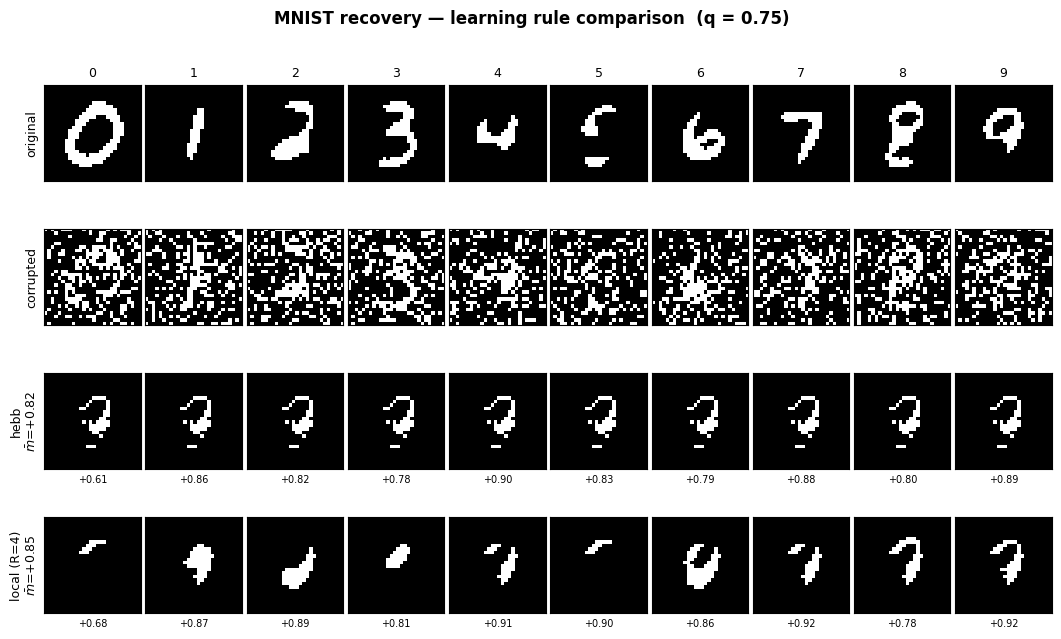

In [22]:
q_mnist = 0.75
corrupted_m = corrupt_patterns(patterns_mnist, q_mnist, method='random', seed=SEED)
corrupted_arr = np.array([c.reshape(28, 28) for c in corrupted_m])

configs = [
    ('hebb',    'synchronous', None),
    ('local',   'synchronous', 4),
]

# build all rows up front: (label, images, per-digit overlaps)
rows = [('original', patterns_mnist, None),
        ('corrupted', corrupted_arr,  None)]

for lr, um, R in configs:
    m = hopfield_model_torch(patterns_mnist, update_method=um,
                                learning_rule=lr, R=R, verbose=False)
    rec = m.correct_patterns(corrupted_arr, max_iter=200)
    ovs = [float(m.overlap(patterns_mnist[d], rec[d])) for d in range(10)]
    rule_label = f'{lr}' + (f' (R={R})' if R is not None else '')
    rows.append((rule_label, rec, ovs))

# plot: 5 rows (original / corrupted / hebb / local) x 10 digits
fig, axes = plt.subplots(len(rows), 10, figsize=(13, 7),
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.35})

for r, (label, imgs, ovs) in enumerate(rows):
    for d in range(10):
        ax = axes[r, d]
        ax.imshow((np.asarray(imgs[d]) + 1) / 2, cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if ovs is not None:
            ax.set_xlabel(f'{ovs[d]:+.2f}', fontsize=7)
        if r == 0:
            ax.set_title(str(d), fontsize=9)

    avg_str = f'\n$\\bar m$={np.mean(ovs):+.2f}' if ovs is not None else ''
    axes[r, 0].set_ylabel(label + avg_str, fontsize=9)

fig.suptitle(f'MNIST recovery — learning rule comparison  (q = {q_mnist})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 — Modern Hopfield network on the digit prototypes

Section 7.3 showed that even with the best learning rule the classical
network has trouble distinguishing some MNIST prototypes — the pairwise
overlap between digits is ≳ 0.6 for several pairs and the sign dynamics
often drifts into a spurious minimum.

The MHN gives us a clean test case: it stores the patterns *as columns
of a matrix* with no Hebbian sum, so there is nothing to saturate. The
only thing that limits it is how similar the prototypes are to each
other — exactly the Experiment 3 regime from Section 6.


/tmp/ipykernel_11293/3426083139.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


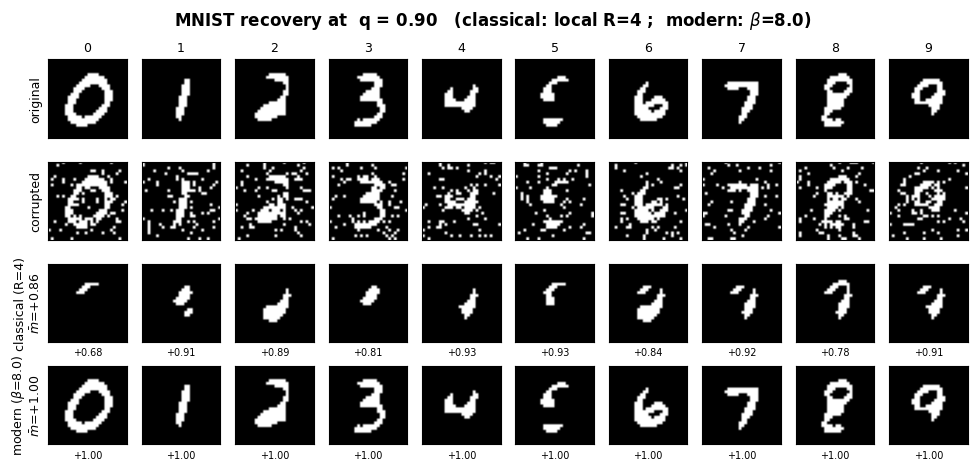

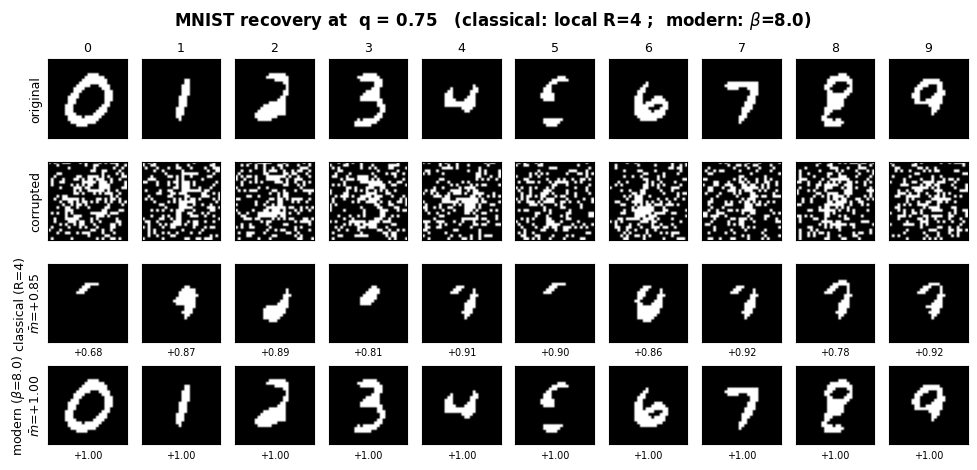

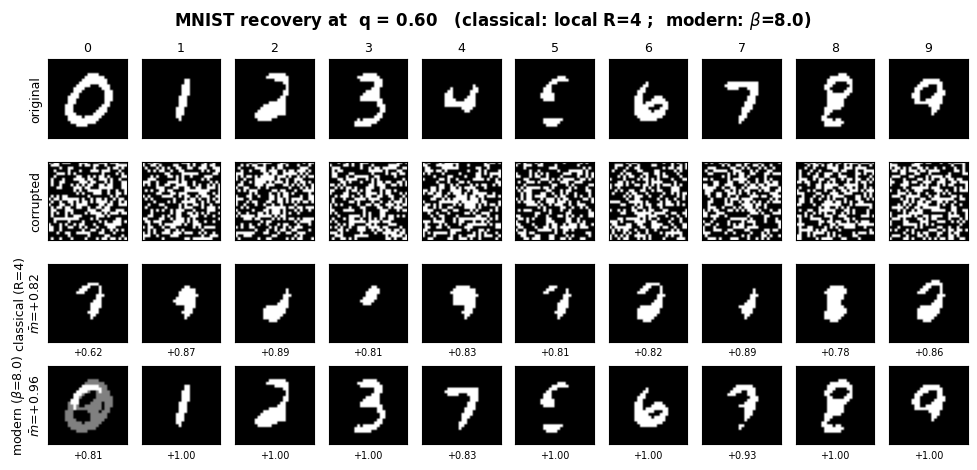

In [14]:
# MNIST: classical vs modern recovery
q_tests_mhn = [0.9, 0.75, 0.6]
N_digits = len(patterns_mnist)

for q_val in q_tests_mhn:
    # corrupt + recover
    corr_mn = corrupt_patterns(patterns_mnist, q_val, method='random', seed=SEED)
    corr_arr = np.array([c.reshape(28, 28) for c in corr_mn])
    rec_cls = model_mnist.correct_patterns(corr_arr, max_iter=200)
    rec_mhn = [mhn_retrieve(c, patterns_mnist, beta=BETA) for c in corr_arr]

    # per-digit overlaps (consistent: model.overlap for classical, mhn_overlap for MHN)
    ov_cls = [float(model_mnist.overlap(patterns_mnist[d], rec_cls[d]))
              for d in range(N_digits)]
    ov_mhn = [mhn_overlap(patterns_mnist[d], rec_mhn[d])
              for d in range(N_digits)]

    # plot: 4 rows (original / corrupted / classical / modern) x 10 digits
    fig, axes = plt.subplots(4, N_digits, figsize=(12, 5),
                             gridspec_kw={'wspace': 0.05, 'hspace': 0.30})

    rows = [
        ('original',           patterns_mnist, None),
        ('corrupted',          corr_arr,       None),
        ('classical (R=4)',    rec_cls,        ov_cls),
        (f'modern ($\\beta$={BETA})', rec_mhn,  ov_mhn),
    ]

    for r, (label, imgs, ovs) in enumerate(rows):
        for d in range(N_digits):
            ax = axes[r, d]
            ax.imshow((np.asarray(imgs[d]) + 1) / 2, cmap='gray', vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])
            if ovs is not None:
                ax.set_xlabel(f'{ovs[d]:+.2f}', fontsize=7)
            if r == 0:
                ax.set_title(str(d), fontsize=9)

        # row label on the left: name + mean overlap (where applicable)
        avg_str = f'\n$\\bar m$={np.mean(ovs):+.2f}' if ovs is not None else ''
        axes[r, 0].set_ylabel(label + avg_str, fontsize=9)

    fig.suptitle(f'MNIST recovery at  q = {q_val:.2f}   '
                 f'(classical: local R=4 ;  modern: $\\beta$={BETA})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

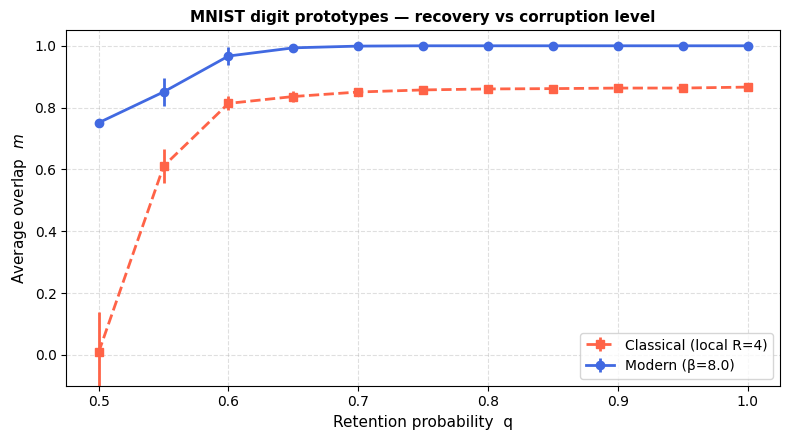

In [23]:
# Quantitative comparison: average overlap vs q on MNIST
q_scan = np.linspace(0.5, 1.0, 11)
N_REPS_mn = 5
ov_cls_mn, ov_mhn_mn = [], []

for q in q_scan:
    cls_runs, mhn_runs = [], []
    for rep in range(N_REPS_mn):
        corr = corrupt_patterns(patterns_mnist, q,
                                    method='random', seed=SEED + rep)
        corr_arr = np.array([c.reshape(28, 28) for c in corr])

        # classical
        rec_c = model_mnist.correct_patterns(corr_arr, max_iter=200)
        cls_runs.append(np.mean([
            float(np.dot(patterns_mnist[d].flatten(), rec_c[d].flatten())
                  / patterns_mnist[d].size)
            for d in range(N_digits)
        ]))

        # modern
        mhn_runs.append(np.mean([
            mhn_overlap(patterns_mnist[d],
                        mhn_retrieve(corr_arr[d], patterns_mnist, beta=BETA))
            for d in range(N_digits)
        ]))

    ov_cls_mn.append((np.mean(cls_runs), np.std(cls_runs)))
    ov_mhn_mn.append((np.mean(mhn_runs), np.std(mhn_runs)))

ov_cls_mn = np.array(ov_cls_mn)
ov_mhn_mn = np.array(ov_mhn_mn)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(q_scan, ov_cls_mn[:, 0], yerr=ov_cls_mn[:, 1], fmt='s--',
            color='tomato',    lw=2, ms=6, label='Classical (local R=4)')
ax.errorbar(q_scan, ov_mhn_mn[:, 0], yerr=ov_mhn_mn[:, 1], fmt='o-',
            color='royalblue', lw=2, ms=6, label=f'Modern (β={BETA})')
ax.set_xlabel('Retention probability  q', fontsize=11)
ax.set_ylabel('Average overlap  $m$', fontsize=11)
ax.set_title('MNIST digit prototypes — recovery vs corruption level',
             fontsize=11, fontweight='bold')
ax.set_ylim(-0.1, 1.05)
ax.grid(True, ls='--', alpha=0.4)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Observation.**
Two things are immediately visible.

1. At every noise level the MHN retrieves the prototypes more reliably
   than the classical network. The gap is widest in the intermediate
   regime ($q\approx0.6$–$0.8$), where the classical sign dynamics often
   drifts into a spurious mixture but the softmax still locks onto the
   closest stored pattern.
2. The MHN curve also descends, but smoothly — there is no "cliff"
   reminiscent of the $P_c$ phase transition. This is consistent with
   the picture from Section 6: in the MHN the bottleneck is pattern
   *similarity* (which is high but still finite for MNIST), not pattern
   *count*.

Together with the energy-landscape view earlier, this is a concrete
demonstration that on realistic, highly-correlated data the modern model
is not just an asymptotic improvement but a practical one.


# Denoising Model — Introduction

Image classification under noise is a fundamental challenge in machine learning.
When an image is corrupted by noise, standard classifiers often fail because the
input distribution shifts far from the clean training data. A more robust approach
is to leverage **denoising** as a core mechanism — not just as a preprocessing
step, but as the classification process itself.

## Model Overview

In this work, we present a **class-conditioned denoising model** that jointly
performs image reconstruction and classification. Given a noisy input image, the
model runs a set of class-specific denoisers in parallel, each attempting to
reconstruct the image under the assumption that it belongs to a particular class.
The quality of each reconstruction is measured by a scoring function $f_{i}$, and
the predicted class is selected as:

$$\hat{y} = \arg\max_i \, f_i$$

The corresponding reconstruction is then returned as the denoised output.

## Key Idea

This formulation naturally ties recognition and generation together — the model
identifies a digit by asking *which class best explains the observed noise pattern*.
Rather than classifying the image directly, the model classifies **by denoising**:
each branch reconstructs the input assuming a specific class, and the best
reconstruction wins.

<img src="./plots/DenoisingModel.jpg" width="1200" height="900" />

In [14]:
from torchvision import datasets, transforms
import numpy as np


#  1. Load MNIST as 64x64, convert to {-1,+1} 

transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),                # (1, 64, 64) in [0,1]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_64,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform_64,
)

def dataset_to_numpy(dataset):
    X_list, y_list = [], []
    for img_tensor, label in dataset:
        img_np = img_tensor.numpy()[0]      # (64, 64)
        X_list.append(img_np)
        y_list.append(label)
    X = np.stack(X_list, axis=0)           # (N, 64, 64)
    y = np.array(y_list, dtype=np.int64)
    return X, y
train_X_01, train_y = dataset_to_numpy(train_dataset)
test_X_01,  test_y  = dataset_to_numpy(test_dataset)

def to_pm1(x):
    return np.where(x > 0.5, 1.0, -1.0).astype(np.float32)

train_X_pm1 = to_pm1(train_X_01)
test_X_pm1  = to_pm1(test_X_01)

#  2. Build per-digit memories (you can tune per_digit) 

digit_memories = {d: [] for d in range(10)}
per_digit = 200   # try 50, 200, etc.

for d in range(10):
    idx = np.where(train_y == d)[0]
    np.random.shuffle(idx)
    idx = idx[:per_digit]
    for i in idx:
        img_2d = train_X_pm1[i]           # (64, 64)
        digit_memories[d].append(img_2d)

#  3. Noise function 

def add_flip_noise(x_pm1, flip_prob=0.3):
    x = x_pm1.flatten().copy()
    mask = np.random.rand(x.size) < flip_prob
    x[mask] *= -1.0
    return x.reshape(x_pm1.shape)

# 4. Pick one test example, corrupt it 

i_test   = 12
clean_img = test_X_pm1[i_test]        # (64, 64)
# clean_img = bcnoisy
label     = test_y[i_test]
noisy_img = add_flip_noise(clean_img, flip_prob=0.3)

print("True label:", label)

#  5. Run 10 MHNs, one per digit 

reconstructions = {}
energies        = {}
overlaps        = {}

f0 = -100

for d in range(10):
    patterns_d = digit_memories[d]

    s_final, traj = mhn_retrieve_continuous(
        noisy_img,
        patterns_d,
        beta=8,
        max_iter=8000,
        tol=1e-14
    )

    reconstructions[d] = s_final
    energies[d]        = mhn_energy(s_final, patterns_d, beta=80)
    overlaps[d]        = mhn_overlap(clean_img, np.sign(s_final))
####

    

    
    coverlap=reconstructions[d].copy()
    cnoisy=noisy_img.copy()
    # cnoisy[coverlap == 1] = 1*2
    cnoisy[coverlap == -1] = -1
    cnoisy[cnoisy == -1] = -2
    # plt.imshow(cnoisy, cmap='gray')
    f=np.mean(cnoisy)
    # f = ssim(cnoisy,coverlap,data_range=1)
    # print(f)
    # if 0.03<np.abs(f0-f):
    if f0<f:
        f0 = f
        ld = d
        bcnoisy=cnoisy
        best = coverlap
        print(f0)
        print(d)
        
# plt.imshow(bcnoisy, cmap='gray')
print(ld)

    



best_digit_energy  = min(energies, key=energies.get)
best_recon_energy  = reconstructions[best_digit_energy]
best_digit_overlap = max(overlaps, key=overlaps.get)
best_recon_overlap = reconstructions[best_digit_overlap]

print("Best by energy:",  best_digit_energy)
print("Best by overlap:", best_digit_overlap)
print("Overlap of true label:", overlaps[label])

# 6. Plot clean / noisy / best reconstructions 

# plt.figure(figsize=(10, 3))

# plt.subplot(1, 4, 1)
# plt.title(f"Clean ({label})")
# plt.imshow(clean_img, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 4, 2)
# plt.title("Noisy")
# plt.imshow(noisy_img, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 4, 3)
# plt.title("Noisy")
# plt.imshow(bcnoisy, cmap='gray')
# plt.axis('off')


# plt.subplot(1, 4, 4)
# plt.title(f"Best overlap {ld}")
# plt.imshow(best, cmap='gray')
# plt.axis('off')

# plt.tight_layout()
# plt.savefig("denoising_test.png")


True label: 9
-1.7861328
0
-1.7766113
2
-1.7553711
4
-1.7312012
9
9
Best by energy: 0
Best by overlap: 9
Overlap of true label: 0.90185546875


<img src="denoising_test.png" width="1200" height="900" />

In [20]:
num_examples = 10
indices = list(range(num_examples))  # you can choose specific indices if you like

all_clean  = []
all_noisy  = []
all_bcnoisy = []
all_best   = []
all_labels = []
all_ld     = []

for i_test in indices:
    # 4. pick test example and corrupt
    clean_img = test_X_pm1[i_test]
    label     = test_y[i_test]
    noisy_img = add_flip_noise(clean_img, flip_prob=0.35)

    print(f"Example {i_test}, true label: {label}")

    # 5. run 10 MHNs, one per digit, with your f-selection logic
    reconstructions = {}
    f0 = -100.0
    ld = None
    bcnoisy = None
    best = None

    for d in range(10):
        patterns_d = digit_memories[d]

        s_final, traj = mhn_retrieve_continuous(
            noisy_img,
            patterns_d,
            beta=8,
            max_iter=90,
            tol=1e-24
        )

        reconstructions[d] = s_final

        coverlap = reconstructions[d].copy()
        cnoisy   = noisy_img.copy()
        cnoisy[coverlap == -1] = -1
        cnoisy[cnoisy == -1] = -2.5
        f = np.mean(cnoisy)

        if f0<f:
            f0 = f
            ld = d
            bcnoisy = cnoisy
            best = coverlap

    # store results for plotting
    all_clean.append(clean_img)
    all_noisy.append(noisy_img)
    all_bcnoisy.append(bcnoisy)
    all_best.append(best)
    all_labels.append(label)
    all_ld.append(ld)

# 6. Plot 10 rows × 4 columns 

rows = num_examples
cols = 4
plt.figure(figsize=(cols * 3, rows * 3))

# for row in range(rows):
#     # Clean
#     plt.subplot(rows, cols, row * cols + 1)
#     plt.title(f"Clean ({all_labels[row]})")
#     plt.imshow(all_clean[row], cmap='gray')
#     plt.axis('off')

#     # Noisy
#     plt.subplot(rows, cols, row * cols + 2)
#     plt.title("Noisy")
#     plt.imshow(all_noisy[row], cmap='gray')
#     plt.axis('off')

#     # bcnoisy
#     plt.subplot(rows, cols, row * cols + 3)
#     plt.title("bcnoisy")
#     plt.imshow(all_bcnoisy[row], cmap='gray')
#     plt.axis('off')

#     # Best overlap
#     plt.subplot(rows, cols, row * cols + 4)
#     plt.title(f"Best")
#     plt.imshow(all_best[row], cmap='gray')
#     plt.axis('off')

# plt.tight_layout()
# plt.show()
# plt.savefig("batch_denoising.png")

Example 0, true label: 7
Example 1, true label: 2
Example 2, true label: 1
Example 3, true label: 0
Example 4, true label: 4
Example 5, true label: 1
Example 6, true label: 4
Example 7, true label: 9
Example 8, true label: 5
Example 9, true label: 9


<Figure size 1200x3000 with 0 Axes>

<Figure size 1200x3000 with 0 Axes>

<img src="./plots/batch_denoising.png" width="1200" height="900" />

## Why this approch works?!
<img src="./plots/J_matrices_per_digit.png" width="1200" height="900" />
<img src="./plots/J_eigenspectra_per_digit.png" width="1200" height="900" />


In the classic Hopfield model textbook cases, we assume the $P$ stored patterns are completely random and orthogonal ($\pm 1$ with equal probability). If they were perfectly orthogonal, you would see $P$ equal eigenvalues.

However, our models are trained on MNIST digits of the **same class** (e.g., Model 0 only sees zeros). These images are not random; they are highly correlated. Every "Digit 0" shares a common geometry: a dark center surrounded by a bright ring of active pixels.

Mathematically, we can decompose each digit pattern $\xi^\mu$ into a **shared prototype (mean template)** $\bar{\xi}$ and some individual fluctuations $\delta\xi^\mu$:

$$\xi^\mu = \bar{\xi} + \delta\xi^\mu$$

When you compute the Hebbian connectivity matrix $J = \sum_{\mu=1}^{P} \xi^\mu (\xi^\mu)^T$, substituting this decomposition yields:

$$J \approx P \cdot (\bar{\xi}\bar{\xi}^T) + \sum_{\mu=1}^{P} \delta\xi^\mu (\delta\xi^\mu)^T$$

---

### The Rank-1 Dominance

The first term, $P \cdot (\bar{\xi}\bar{\xi}^T)$, is a **rank-1 matrix** formed by the outer product of the average digit template with itself.

* **Single Non-Zero Eigenvalue:** A rank-1 matrix has exactly **one** non-zero eigenvalue.
* **Scale of the Mode:** The value of this dominant eigenvalue is roughly proportional to $P \times \|\bar{\xi}\|^2$. Because $P=300$ and the pixels are highly correlated, this single mode shoots up to the order of $\sim 200\text{–}250$ that you see on our plots.
* **The Template Eigenvector:** The corresponding eigenvector is nothing less than the **archetypal template** of that specific digit.

The remaining fluctuations $\delta\xi^\mu$ act like random noise. They form the second term, which creates the massive "bulk" of eigenvalues centered near zero (resembling a **Marchenko-Pastur distribution** from random matrix theory).


<img src="./plots/MHN_eigenspectra_per_digit.png" width="1200" height="900" />
<img src="./plots/MHN_gram_per_digit.png" width="1200" height="900" />

*to avoid rewritting repetitive codes I sperate scripts of these resualts   (plot_j_matrices.py and plot_mhn_gram.py)

<img src="./plots/print.jpg" width="1200" height="900" />

--- 

## 8 — Conclusions

**Pattern storage (Part A).** The coupling matrix $J$ encodes each stored
pattern as a direction in the $N$-dimensional spin space. The eigenvalue
spectrum of $J$ shows $P$ large eigenvalues (≈1 each, one per stored pattern)
separated from a bulk of noise eigenvalues concentrated near zero — a direct
signature of the signal-to-noise structure familiar from random matrix theory.

**Corruption and recovery (Parts B–C).** The synchronous sign rule converges
in as few as 2 iterations on well-separated patterns, as confirmed by the
energy trace. Spatially structured corruption (radial, block, gradient)
produces qualitatively different initial states but the network recovers
equally well when $P \ll P_c$. An important symmetry of the Hopfield energy is
that $-\xi^\mu$ is also an attractor: for $q < 0.5$ (more than 50% of spins
flipped) the network consistently converges to the *inverted* pattern, driving
the overlap to $m \approx -1$.

**Storage capacity (Part D).** The overlap $m(q)$ shows a clear
phase-transition-like drop centred near $q^* \approx 0.5$ for all tested
values of $P$. The critical $q^*$ is only weakly sensitive to $P$ in the
regime $P \ll P_c$; what changes is the steepness and the depth of the
negative tail. The capacity sweep confirms that $m$ degrades with increasing
$P$, but the transition is smooth rather than sharp — consistent with
finite-$N$ rounding of the mean-field discontinuity. Extending the sweep
beyond $P_c \approx 27$ (= 0.138 × 196) would sharpen the signal.

**MNIST (Part 7).** Storing the 10 digit prototypes (P = 10, well within
$P_c \approx 108$ for $N = 28^2$) reveals an unexpected obstacle: the
pairwise overlap between prototypes ranges from 0.58 to 0.90 (interference
$I = 0.74$), far above the values seen with random patterns. This is not a
failure of the learning rule but a geometric effect — all 10 digits share the
same large black background, so the majority of the $N = 784$ spins are −1 in
every pattern, creating a strong spurious correlation. As a result the network
struggles to distinguish digits despite being formally within capacity. The
upscaling pre-processing (majority vote at 112×112, pooled back to 28×28)
produces visually cleaner prototypes at low resolution, where background noise
is proportionally larger, but has negligible effect at the native 28×28
resolution where the majority vote is already stable.



**Modern Hopfield network (Section 6 extended, Section 7.4).** Replacing the
quadratic Ising energy with the log-sum-exp energy of Ramsauer et al. (2020)
lifts essentially every classical limit observed above. At $N\!=\!196$ the
classical model collapses past $P_c\!\approx\!27$, while the MHN sustains
$m\!\approx\!1$ for $P\!=\!50$ at $q\!=\!0.8$. The trade-off is a new
failure mode: when the stored patterns become nearly identical the softmax
can no longer discriminate them and the retrieval blends them together —
the relevant parameter is **pairwise overlap**, not pattern count. On
MNIST this trade-off is favourable: the prototype overlaps are high
(Section 7.2) but the digits remain pairwise distinguishable, and the MHN
recovers more digits correctly at every corruption level than the best
classical learning rule. Finally, the MHN update
$\mathbf{S}\leftarrow X\,\text{softmax}(\beta X^\top\mathbf{S})$ is
mathematically identical to one attention head with the spin state as the
query and the stored patterns as keys and values — providing a direct
link between the statistical mechanics of associative memories and the
core operation inside a Transformer.



**Parallel Hopfield models**
we build 10 digit-specific Hopfield models (classical or modern), run them in parallel on a noisy test image, and pick the class whose reconstruction best explains the input.